In [ ]:
# CELL 1 — INSTALL LIBRARIES
!pip install shap lime dice-ml imbalanced-learn xgboost tensorflow ucimlrepo --quiet

print("All libraries installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 44.9 MB/s eta 0:00:00
All libraries installed successfully.


In [ ]:
# CELL 2 — IMPORT ALL LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import shap
import lime
import lime.lime_tabular
import dice_ml

from ucimlrepo import fetch_ucirepo

print("All libraries imported successfully.")

All libraries imported successfully.


In [ ]:
# CELL 3 — MOUNT GOOGLE DRIVE AND LOAD DATASETS
from google.colab import drive
drive.mount('/content/drive')

# Load PIMA dataset from Google Drive
df_pima = pd.read_csv('/content/drive/MyDrive/diabetes.csv')
print("PIMA dataset loaded successfully.")
print(f"Shape: {df_pima.shape}")

# Load CDC dataset from UCI directly
cdc = fetch_ucirepo(id=891)
df_cdc = pd.concat([cdc.data.features, cdc.data.targets], axis=1)
print("\nCDC dataset loaded successfully.")
print(f"Shape: {df_cdc.shape}")

Mounted at /content/drive
PIMA dataset loaded successfully.
Shape: (768, 9)

CDC dataset loaded successfully.
Shape: (253680, 22)


In [ ]:
# CELL 4 — PIMA EXPLORATORY DATA ANALYSIS
print("=" * 50)
print("PIMA DATASET — EDA")
print("=" * 50)

print("\n--- Dataset Info ---")
print(df_pima.info())

print("\n--- Descriptive Statistics ---")
print(df_pima.describe())

print("\n--- Class Distribution ---")
print(df_pima['Outcome'].value_counts())
print(f"\nClass imbalance ratio: {df_pima['Outcome'].value_counts()[0] / df_pima['Outcome'].value_counts()[1]:.2f}:1")

print("\n--- Null Check ---")
print(df_pima.isnull().sum())

print("\n--- Zero Value Check (biologically impossible) ---")
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zeros:
    zero_count = (df_pima[col] == 0).sum()
    print(f"{col}: {zero_count} zeros ({zero_count/len(df_pima)*100:.1f}%)")

PIMA DATASET — EDA

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

--- Descriptive Statistics ---
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      

In [ ]:
# CELL 5 — CDC EXPLORATORY DATA ANALYSIS
print("=" * 50)
print("CDC DATASET — EDA")
print("=" * 50)

print("\n--- Dataset Info ---")
print(df_cdc.info())

print("\n--- Class Distribution ---")
print(df_cdc['Diabetes_binary'].value_counts())
print(f"\nClass imbalance ratio: {df_cdc['Diabetes_binary'].value_counts()[0] / df_cdc['Diabetes_binary'].value_counts()[1]:.2f}:1")

print("\n--- Null Check ---")
print(df_cdc.isnull().sum())

print("\n--- Feature Types ---")
print(f"Total features: {df_cdc.shape[1] - 1}")
print(f"Binary features: {sum(df_cdc.drop('Diabetes_binary', axis=1).nunique() == 2)}")
print(f"Continuous features: {sum(df_cdc.drop('Diabetes_binary', axis=1).nunique() > 2)}")

CDC DATASET — EDA

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                253680 non-null  int64
 1   HighChol              253680 non-null  int64
 2   CholCheck             253680 non-null  int64
 3   BMI                   253680 non-null  int64
 4   Smoker                253680 non-null  int64
 5   Stroke                253680 non-null  int64
 6   HeartDiseaseorAttack  253680 non-null  int64
 7   PhysActivity          253680 non-null  int64
 8   Fruits                253680 non-null  int64
 9   Veggies               253680 non-null  int64
 10  HvyAlcoholConsump     253680 non-null  int64
 11  AnyHealthcare         253680 non-null  int64
 12  NoDocbcCost           253680 non-null  int64
 13  GenHlth               253680 non-null  int64
 14  MentHlth              253680 non-null  int64

In [ ]:
# CELL 6 — PIMA PREPROCESSING: ZERO VALUE CLEANING
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace biologically impossible zeros with NaN
df_pima[cols_with_zeros] = df_pima[cols_with_zeros].replace(0, np.nan)

# Fill NaN with column median
df_pima[cols_with_zeros] = df_pima[cols_with_zeros].fillna(df_pima[cols_with_zeros].median())

# Verify no nulls remain
print("--- Null check after cleaning ---")
print(df_pima.isnull().sum())

# Verify zeros are gone
print("\n--- Minimum values after cleaning ---")
print(df_pima[cols_with_zeros].min())

print("\nPIMA zero value cleaning complete.")

--- Null check after cleaning ---
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

--- Minimum values after cleaning ---
Glucose          44.0
BloodPressure    24.0
SkinThickness     7.0
Insulin          14.0
BMI              18.2
dtype: float64

PIMA zero value cleaning complete.


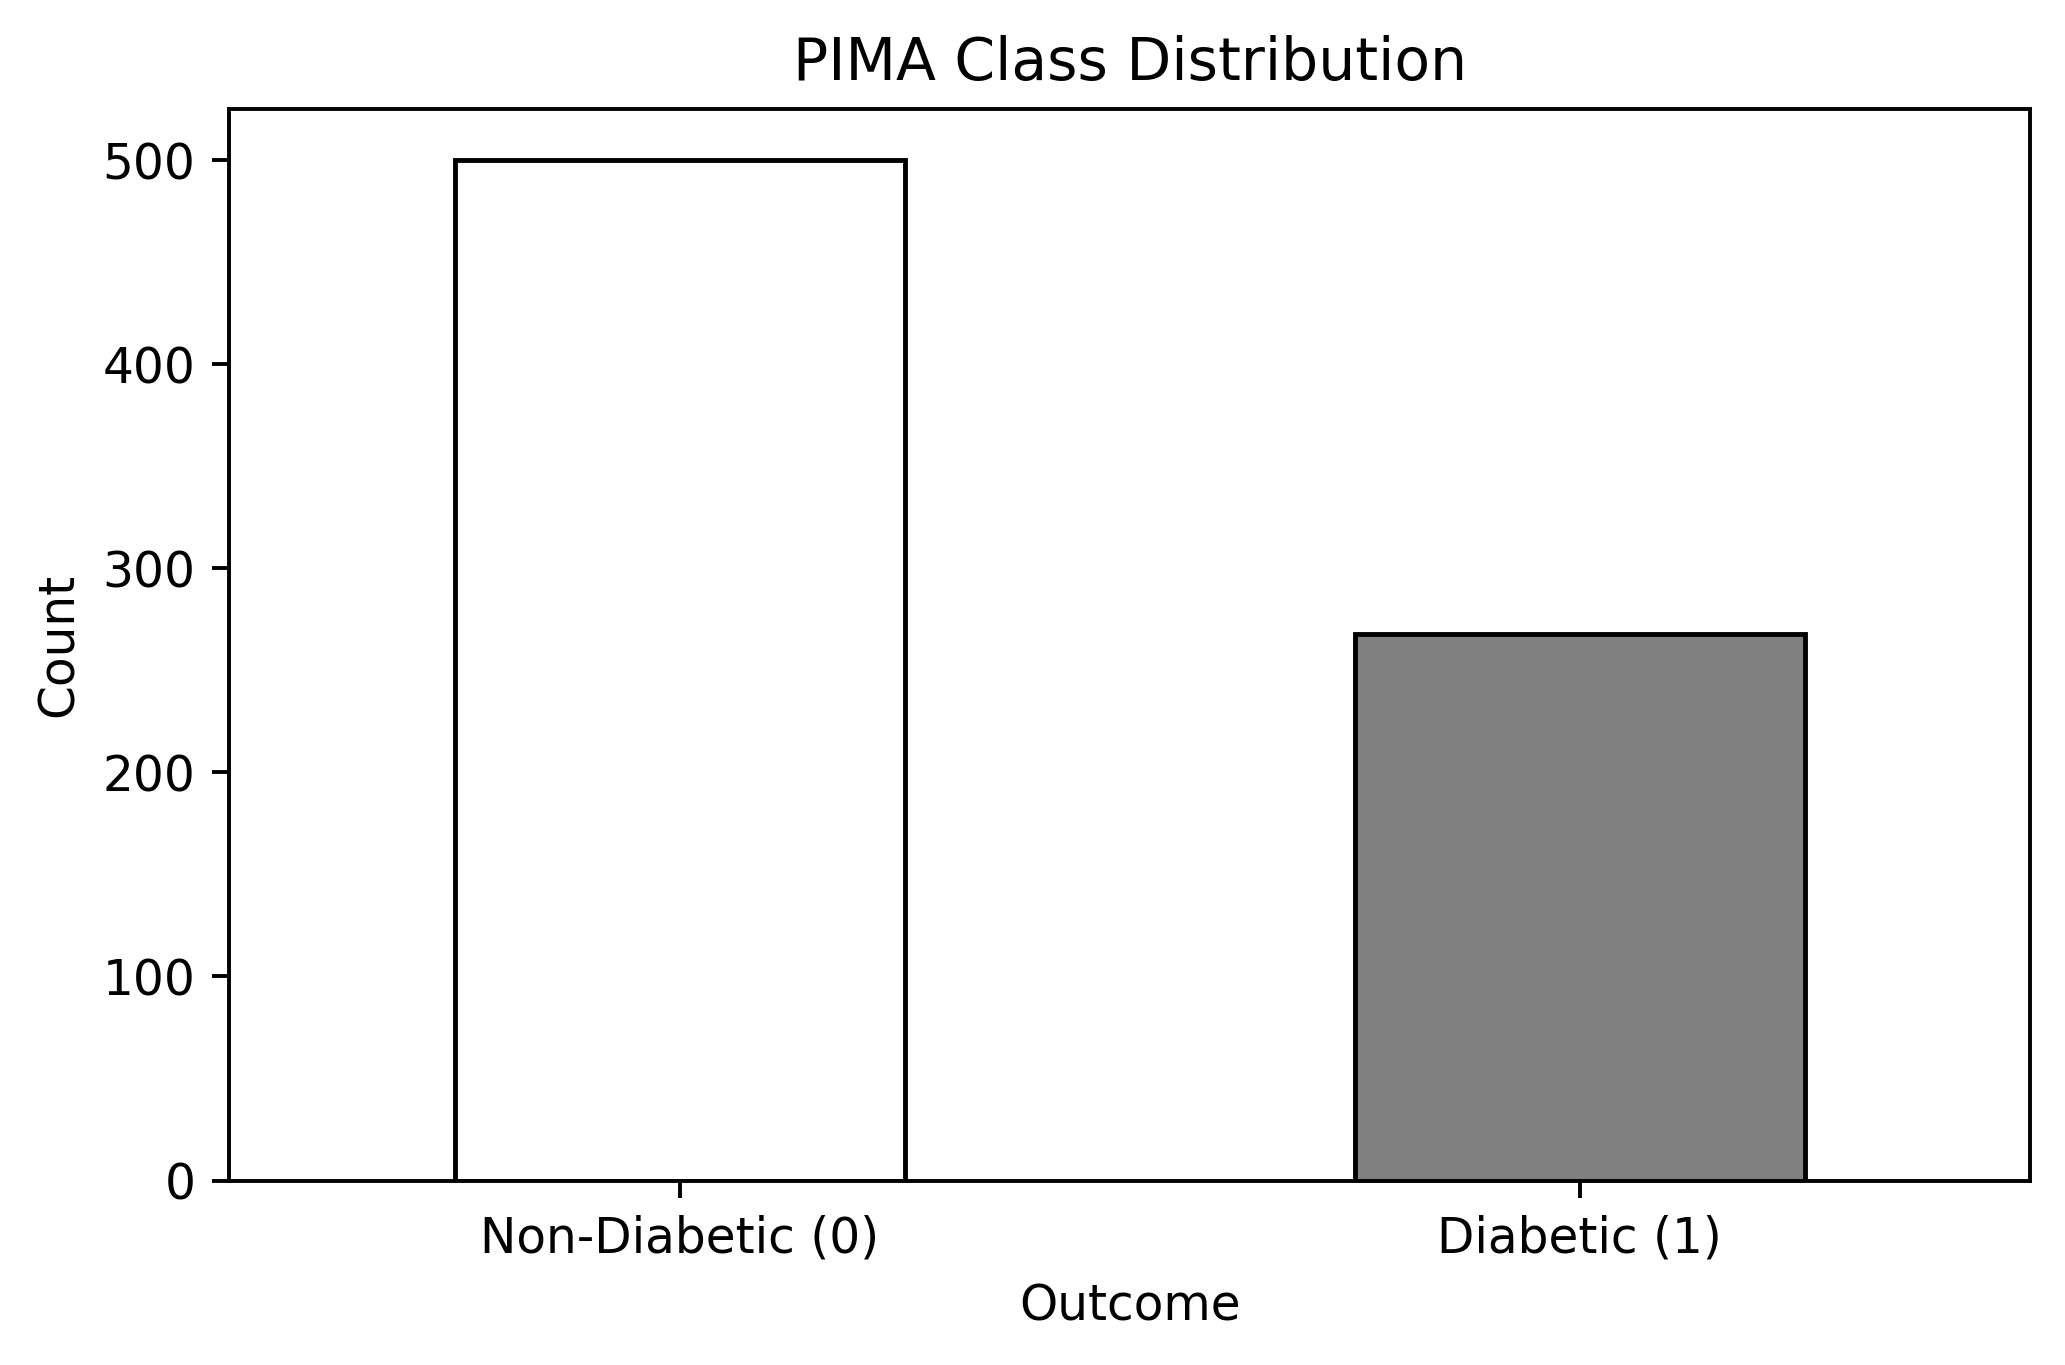

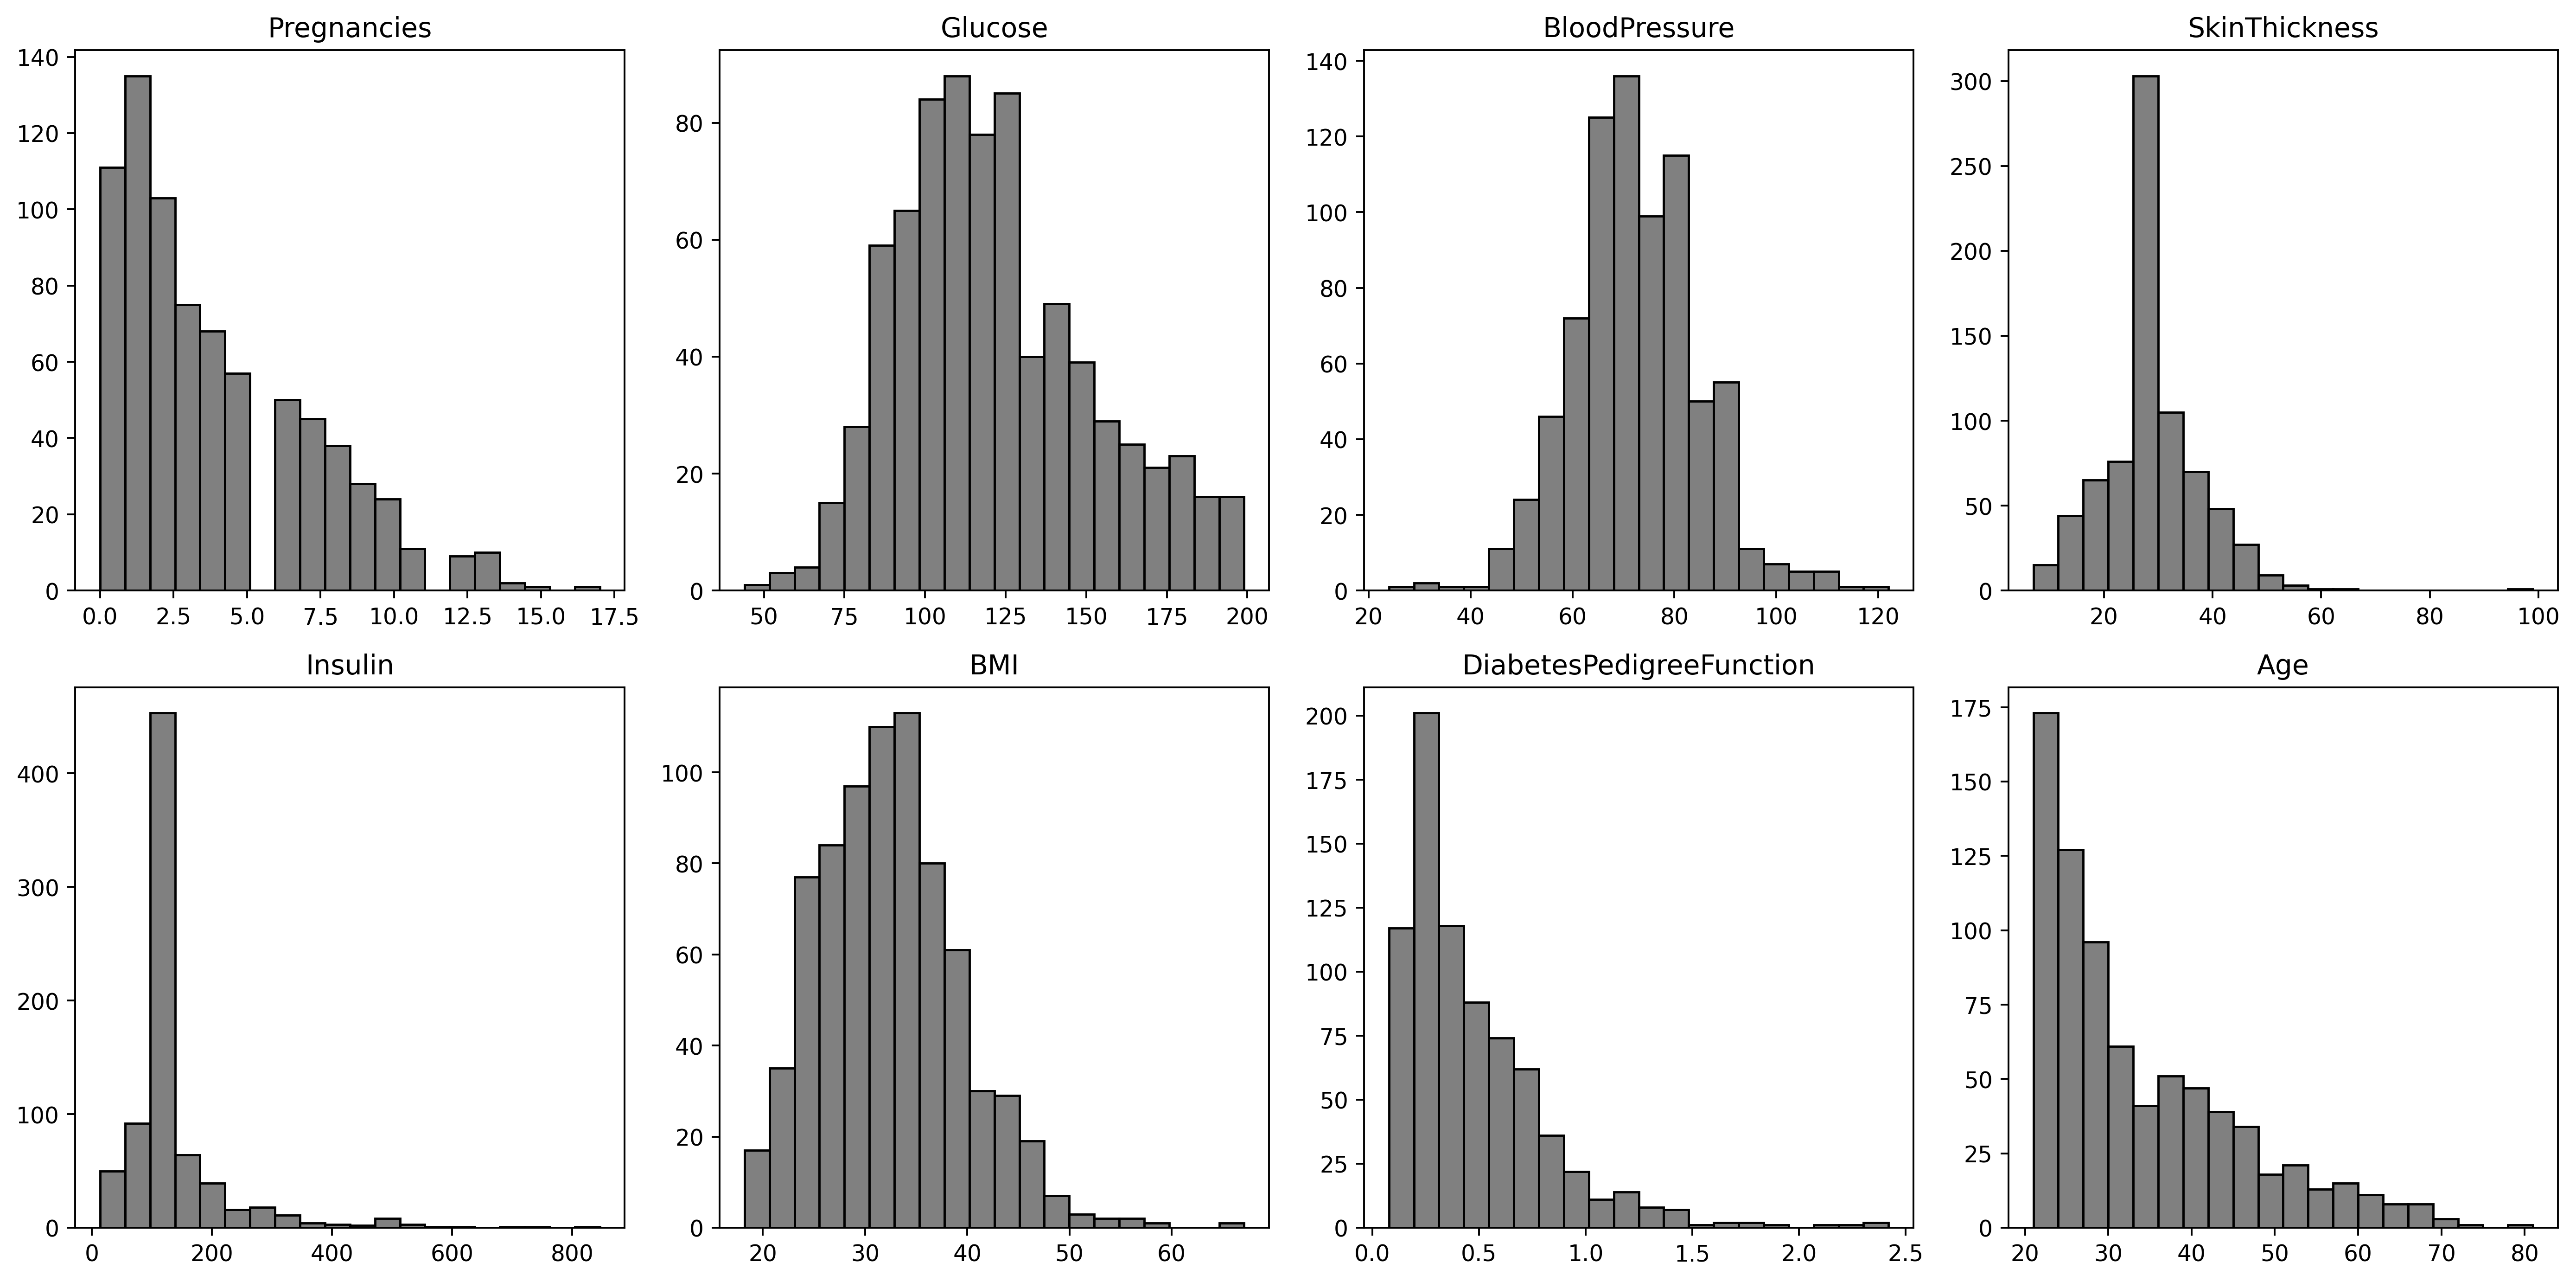

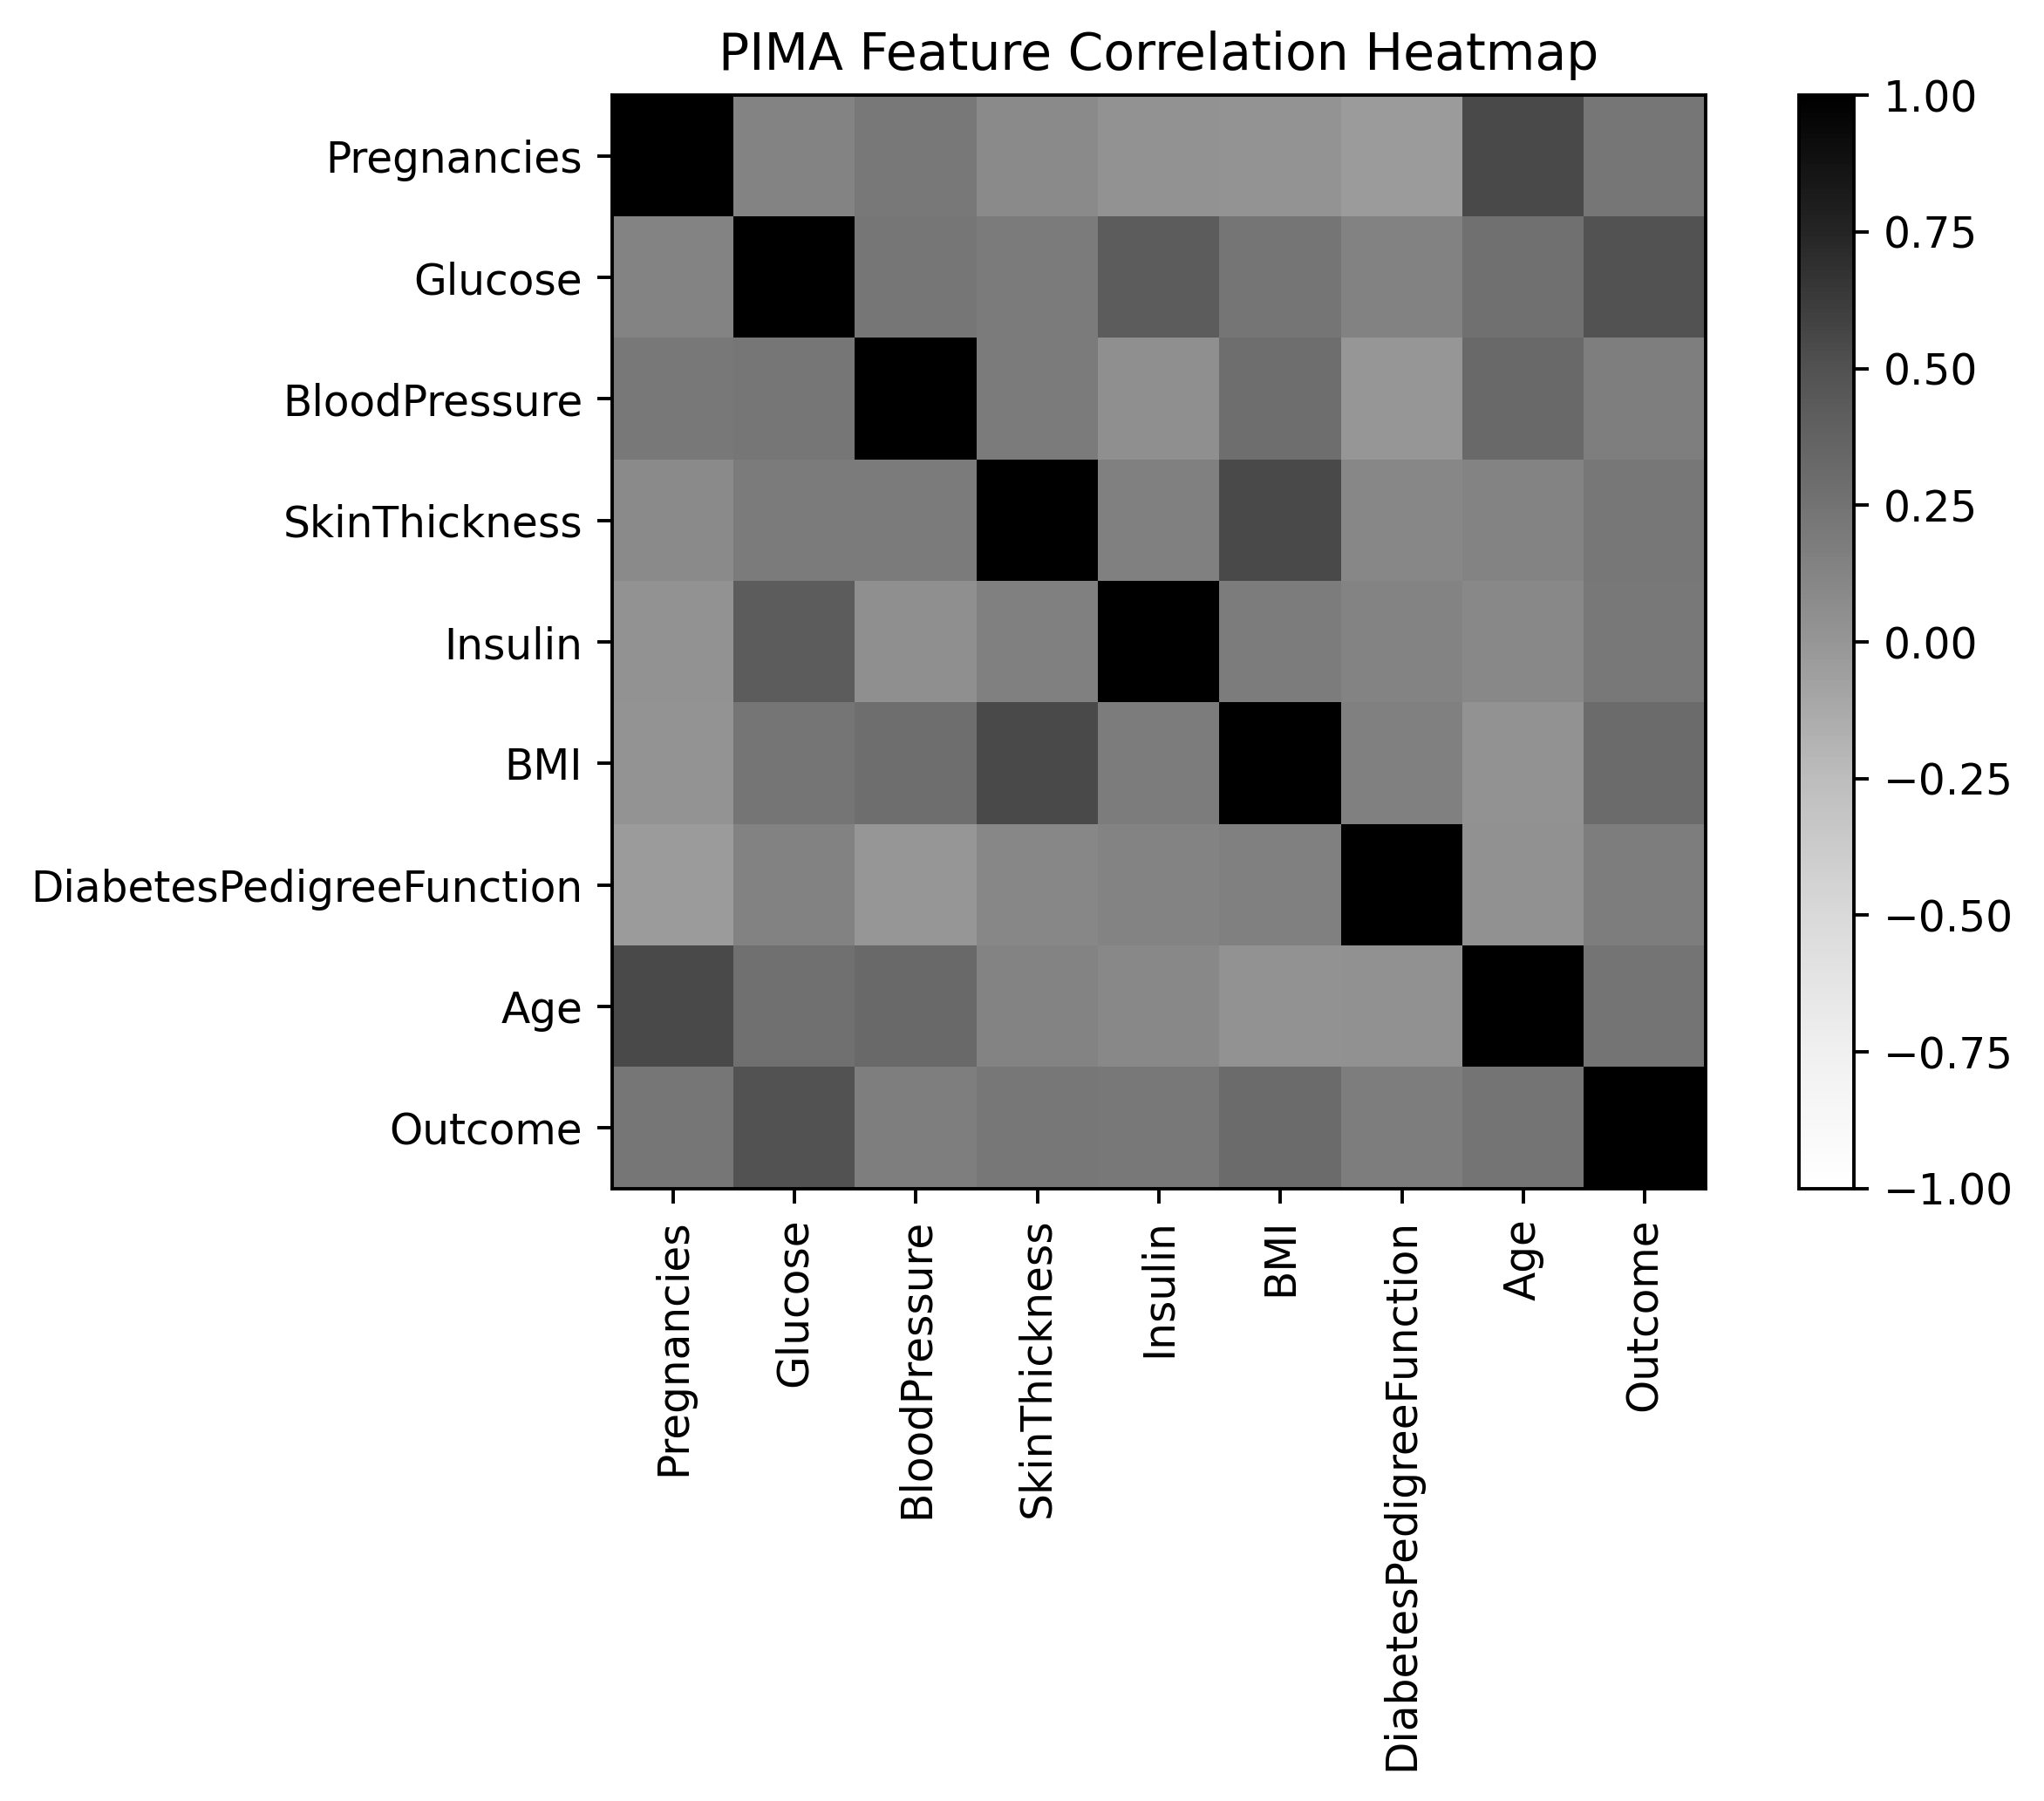

All 3 PIMA plots saved to Google Drive.


In [ ]:
# CELL 7 — PIMA PLOTS (BLACK AND WHITE, 350 DPI)
plt.rcParams['figure.dpi'] = 350
plt.rcParams['savefig.dpi'] = 350

# Plot 1 — Class Distribution
fig, ax = plt.subplots(figsize=(6, 4))
df_pima['Outcome'].value_counts().plot(kind='bar', ax=ax,
                                        color=['white', 'gray'],
                                        edgecolor='black')
ax.set_title('PIMA Class Distribution')
ax.set_xlabel('Outcome')
ax.set_ylabel('Count')
ax.set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'], rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/pima_class_distribution.png',
            dpi=350, bbox_inches='tight')
plt.show()

# Plot 2 — Feature Histograms
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
for i, feature in enumerate(features):
    row, col = i // 4, i % 4
    axes[row, col].hist(df_pima[feature], bins=20,
                        color='gray', edgecolor='black')
    axes[row, col].set_title(feature)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/pima_histograms.png',
            dpi=350, bbox_inches='tight')
plt.show()

# Plot 3 — Correlation Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
corr = df_pima.corr()
im = ax.imshow(corr, cmap='Greys', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
plt.colorbar(im)
ax.set_title('PIMA Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/pima_correlation_heatmap.png',
            dpi=350, bbox_inches='tight')
plt.show()

print("All 3 PIMA plots saved to Google Drive.")

In [ ]:
# CELL 8 — PIMA TRAIN-TEST SPLIT + SMOTE + SCALING

# Split into X and y
X_pima = df_pima.drop('Outcome', axis=1)
y_pima = df_pima['Outcome']

feature_names_pima = X_pima.columns.tolist()

# Train-test split (80/20, stratified, random_state=42)
X_train_pima, X_test_pima, y_train_pima, y_test_pima = train_test_split(
    X_pima, y_pima,
    test_size=0.2,
    stratify=y_pima,
    random_state=42
)

print("--- Before SMOTE ---")
print(y_train_pima.value_counts())

# Apply SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_pima_smote, y_train_pima_smote = smote.fit_resample(
    X_train_pima, y_train_pima
)

print("\n--- After SMOTE ---")
print(y_train_pima_smote.value_counts())

# Apply StandardScaler — fit on train only, transform both
scaler_pima = StandardScaler()
X_train_pima_scaled = scaler_pima.fit_transform(X_train_pima_smote)
X_test_pima_scaled = scaler_pima.transform(X_test_pima)

print("\n--- Shapes after preprocessing ---")
print(f"X_train_pima_scaled: {X_train_pima_scaled.shape}")
print(f"X_test_pima_scaled:  {X_test_pima_scaled.shape}")
print(f"y_test_pima:         {y_test_pima.shape}")

print("\nPIMA preprocessing complete.")

--- Before SMOTE ---
Outcome
0    400
1    214
Name: count, dtype: int64

--- After SMOTE ---
Outcome
0    400
1    400
Name: count, dtype: int64

--- Shapes after preprocessing ---
X_train_pima_scaled: (800, 8)
X_test_pima_scaled:  (154, 8)
y_test_pima:         (154,)

PIMA preprocessing complete.


In [ ]:
# CELL 9 — CDC TRAIN-TEST SPLIT + SMOTE + SCALING

# Split into X and y
X_cdc = df_cdc.drop('Diabetes_binary', axis=1)
y_cdc = df_cdc['Diabetes_binary']

feature_names_cdc = X_cdc.columns.tolist()

# Train-test split (80/20, stratified, random_state=42)
X_train_cdc, X_test_cdc, y_train_cdc, y_test_cdc = train_test_split(
    X_cdc, y_cdc,
    test_size=0.2,
    stratify=y_cdc,
    random_state=42
)

print("--- Before SMOTE ---")
print(y_train_cdc.value_counts())

# Apply SMOTE on training data only
smote_cdc = SMOTE(random_state=42)
X_train_cdc_smote, y_train_cdc_smote = smote_cdc.fit_resample(
    X_train_cdc, y_train_cdc
)

print("\n--- After SMOTE ---")
print(y_train_cdc_smote.value_counts())

# Apply StandardScaler — fit on train only, transform both
scaler_cdc = StandardScaler()
X_train_cdc_scaled = scaler_cdc.fit_transform(X_train_cdc_smote)
X_test_cdc_scaled = scaler_cdc.transform(X_test_cdc)

print("\n--- Shapes after preprocessing ---")
print(f"X_train_cdc_scaled: {X_train_cdc_scaled.shape}")
print(f"X_test_cdc_scaled:  {X_test_cdc_scaled.shape}")
print(f"y_test_cdc:         {y_test_cdc.shape}")

print("\nCDC preprocessing complete.")

--- Before SMOTE ---
Diabetes_binary
0    174667
1     28277
Name: count, dtype: int64

--- After SMOTE ---
Diabetes_binary
0    174667
1    174667
Name: count, dtype: int64

--- Shapes after preprocessing ---
X_train_cdc_scaled: (349334, 21)
X_test_cdc_scaled:  (50736, 21)
y_test_cdc:         (50736,)

CDC preprocessing complete.


In [ ]:
# CELL 10 — XGBOOST BASELINE ON PIMA
xgb_baseline_pima = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_baseline_pima.fit(X_train_pima_scaled, y_train_pima_smote)

# Predictions
y_pred_xgb_base_pima = xgb_baseline_pima.predict(X_test_pima_scaled)
y_proba_xgb_base_pima = xgb_baseline_pima.predict_proba(X_test_pima_scaled)[:, 1]

print("=== XGBoost Baseline — PIMA ===")
print(f"Accuracy:  {accuracy_score(y_test_pima, y_pred_xgb_base_pima):.4f}")
print(f"Precision: {precision_score(y_test_pima, y_pred_xgb_base_pima):.4f}")
print(f"Recall:    {recall_score(y_test_pima, y_pred_xgb_base_pima):.4f}")
print(f"F1-score:  {f1_score(y_test_pima, y_pred_xgb_base_pima):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test_pima, y_proba_xgb_base_pima):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test_pima, y_pred_xgb_base_pima,
      target_names=['Non-Diabetic (0)', 'Diabetic (1)']))

=== XGBoost Baseline — PIMA ===
Accuracy:  0.7403
Precision: 0.6207
Recall:    0.6667
F1-score:  0.6429
AUC-ROC:   0.8096

=== Classification Report ===
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.81      0.78      0.80       100
    Diabetic (1)       0.62      0.67      0.64        54

        accuracy                           0.74       154
       macro avg       0.72      0.72      0.72       154
    weighted avg       0.75      0.74      0.74       154



In [ ]:
# CELL 11 — XGBOOST TUNED (CORRECTED PIPELINE) ON PIMA
pipeline_pima = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(random_state=42, eval_metric='logloss'))
])

param_dist = {
    'xgb__n_estimators': [100, 200, 300, 400],
    'xgb__max_depth': [3, 4, 5, 6, 7],
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'xgb__subsample': [0.7, 0.8, 0.9, 1.0],
    'xgb__scale_pos_weight': [1, 1.5, 2]
}

xgb_search_pima = RandomizedSearchCV(
    pipeline_pima,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1
)

# Fit on raw training data
xgb_search_pima.fit(X_train_pima, y_train_pima)

print("=== Best Parameters (PIMA) ===")
print(xgb_search_pima.best_params_)
print(f"\nBest CV F1 (corrected): {xgb_search_pima.best_score_:.4f}")

# Evaluate on test set
best_xgb_pima = xgb_search_pima.best_estimator_
y_pred_xgb_tuned_pima = best_xgb_pima.predict(X_test_pima)
y_proba_xgb_tuned_pima = best_xgb_pima.predict_proba(X_test_pima)[:, 1]

print("\n=== XGBoost Tuned — PIMA ===")
print(f"Accuracy:  {accuracy_score(y_test_pima, y_pred_xgb_tuned_pima):.4f}")
print(f"Precision: {precision_score(y_test_pima, y_pred_xgb_tuned_pima):.4f}")
print(f"Recall:    {recall_score(y_test_pima, y_pred_xgb_tuned_pima):.4f}")
print(f"F1-score:  {f1_score(y_test_pima, y_pred_xgb_tuned_pima):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test_pima, y_proba_xgb_tuned_pima):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test_pima, y_pred_xgb_tuned_pima,
      target_names=['Non-Diabetic (0)', 'Diabetic (1)']))

=== Best Parameters (PIMA) ===
{'xgb__subsample': 0.9, 'xgb__scale_pos_weight': 1.5, 'xgb__n_estimators': 300, 'xgb__max_depth': 3, 'xgb__learning_rate': 0.01}

Best CV F1 (corrected): 0.6793

=== XGBoost Tuned — PIMA ===
Accuracy:  0.7208
Precision: 0.5679
Recall:    0.8519
F1-score:  0.6815
AUC-ROC:   0.8216

=== Classification Report ===
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.89      0.65      0.75       100
    Diabetic (1)       0.57      0.85      0.68        54

        accuracy                           0.72       154
       macro avg       0.73      0.75      0.72       154
    weighted avg       0.78      0.72      0.73       154



In [ ]:
# CELL 12 — NEURAL NETWORK WITH DROPOUT ON PIMA
tf.random.set_seed(42)

nn_model_pima = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_pima_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

nn_model_pima.compile(optimizer='adam',
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss',
                            patience=5,
                            restore_best_weights=True)

history_pima = nn_model_pima.fit(
    X_train_pima_scaled, y_train_pima_smote,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

# Predictions
y_proba_nn_pima = nn_model_pima.predict(X_test_pima_scaled).flatten()
y_pred_nn_pima = (y_proba_nn_pima >= 0.5).astype(int)

print("=== Neural Network — PIMA ===")
print(f"Accuracy:  {accuracy_score(y_test_pima, y_pred_nn_pima):.4f}")
print(f"Precision: {precision_score(y_test_pima, y_pred_nn_pima):.4f}")
print(f"Recall:    {recall_score(y_test_pima, y_pred_nn_pima):.4f}")
print(f"F1-score:  {f1_score(y_test_pima, y_pred_nn_pima):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test_pima, y_proba_nn_pima):.4f}")

print(f"\nEarly stopping triggered at epoch: {early_stop.stopped_epoch}")

print("\n=== Classification Report ===")
print(classification_report(y_test_pima, y_pred_nn_pima,
      target_names=['Non-Diabetic (0)', 'Diabetic (1)']))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
=== Neural Network — PIMA ===
Accuracy:  0.7208
Precision: 0.6078
Recall:    0.5741
F1-score:  0.5905
AUC-ROC:   0.8148

Early stopping triggered at epoch: 37

=== Classification Report ===
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.78      0.80      0.79       100
    Diabetic (1)       0.61      0.57      0.59        54

        accuracy                           0.72       154
       macro avg       0.69      0.69      0.69       154
    weighted avg       0.72      0.72      0.72       154



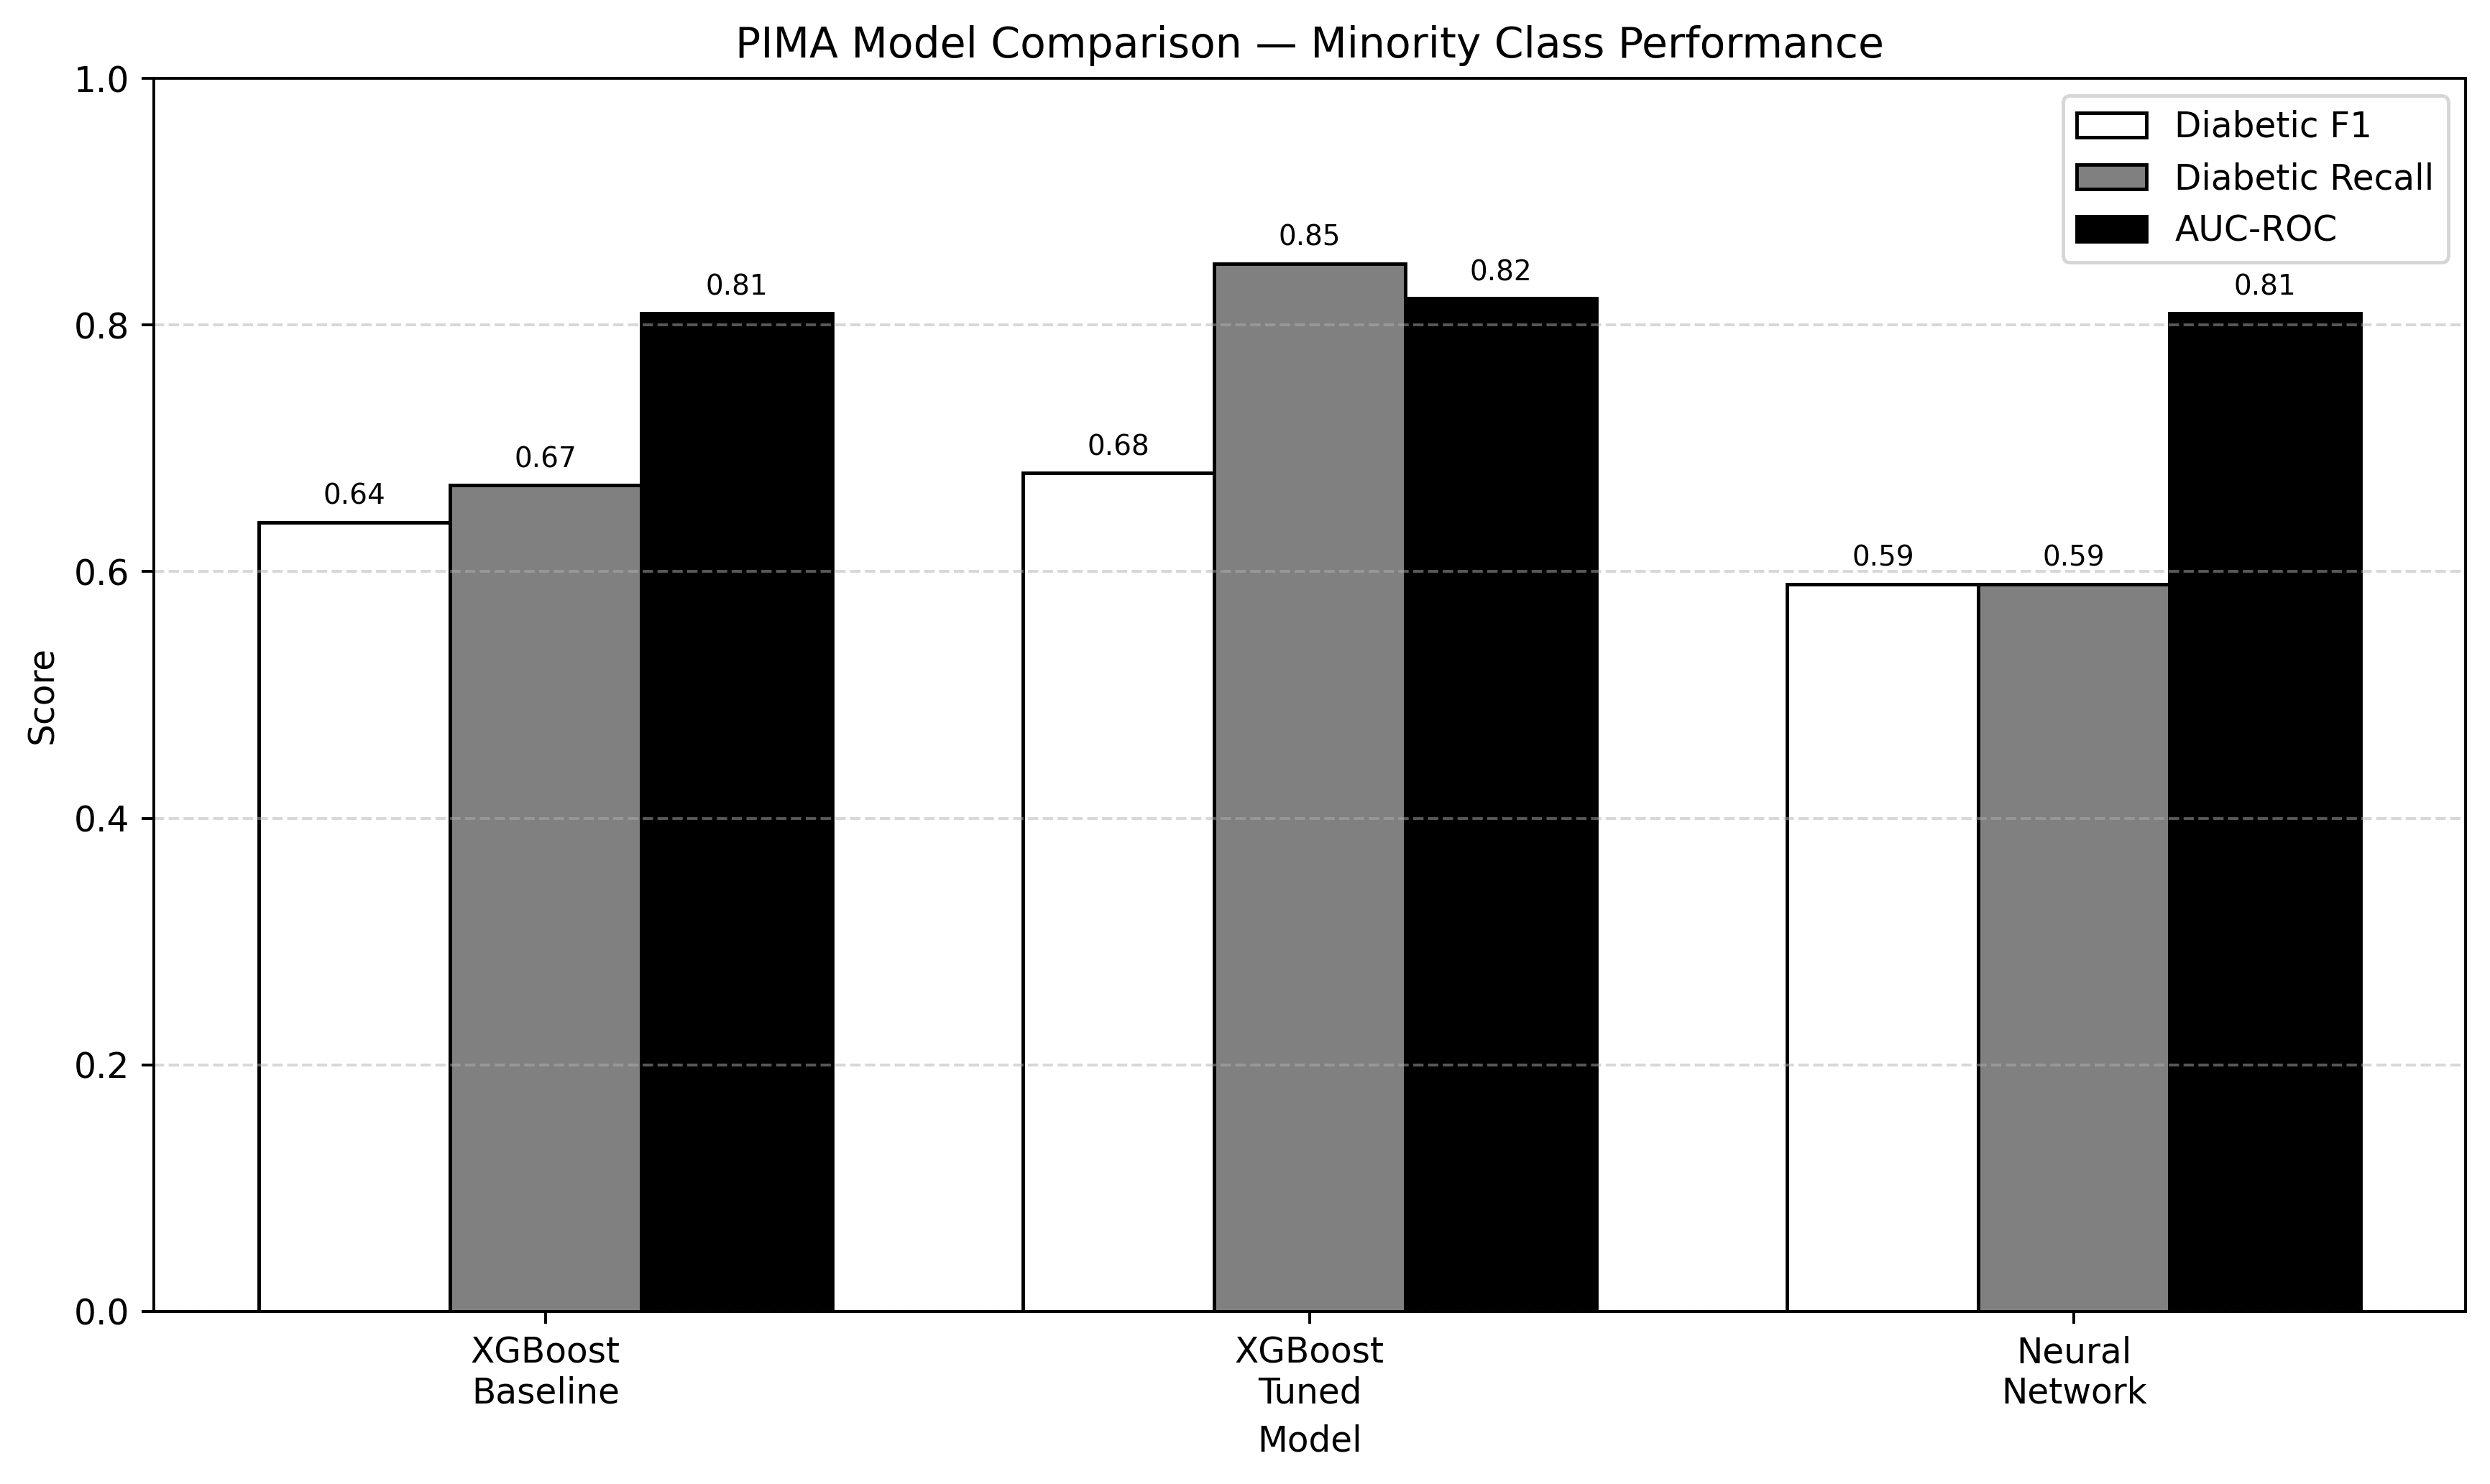

PIMA model comparison plot saved to Google Drive.


In [ ]:
# CELL 13 — PIMA MODEL COMPARISON PLOT
models = ['XGBoost\nBaseline', 'XGBoost\nTuned', 'Neural\nNetwork']

metrics = {
    'Diabetic F1': [0.64, 0.68, 0.59],
    'Diabetic Recall': [0.67, 0.85, 0.59],
    'AUC-ROC': [0.8096, 0.8216, 0.8096]
}

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width, metrics['Diabetic F1'],
               width, label='Diabetic F1',
               color='white', edgecolor='black')
bars2 = ax.bar(x, metrics['Diabetic Recall'],
               width, label='Diabetic Recall',
               color='gray', edgecolor='black')
bars3 = ax.bar(x + width, metrics['AUC-ROC'],
               width, label='AUC-ROC',
               color='black', edgecolor='black')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('PIMA Model Comparison — Minority Class Performance')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars3:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/pima_model_comparison.png',
            dpi=350, bbox_inches='tight')
plt.show()

print("PIMA model comparison plot saved to Google Drive.")

SHAP values calculated successfully.
Shape: (154, 8)

=== Global Feature Importance (Full Test Set) ===
Glucose                     0.838812
BMI                         0.530606
Age                         0.285979
DiabetesPedigreeFunction    0.226166
Insulin                     0.099171
SkinThickness               0.057136
BloodPressure               0.055761
Pregnancies                 0.032571
dtype: float32


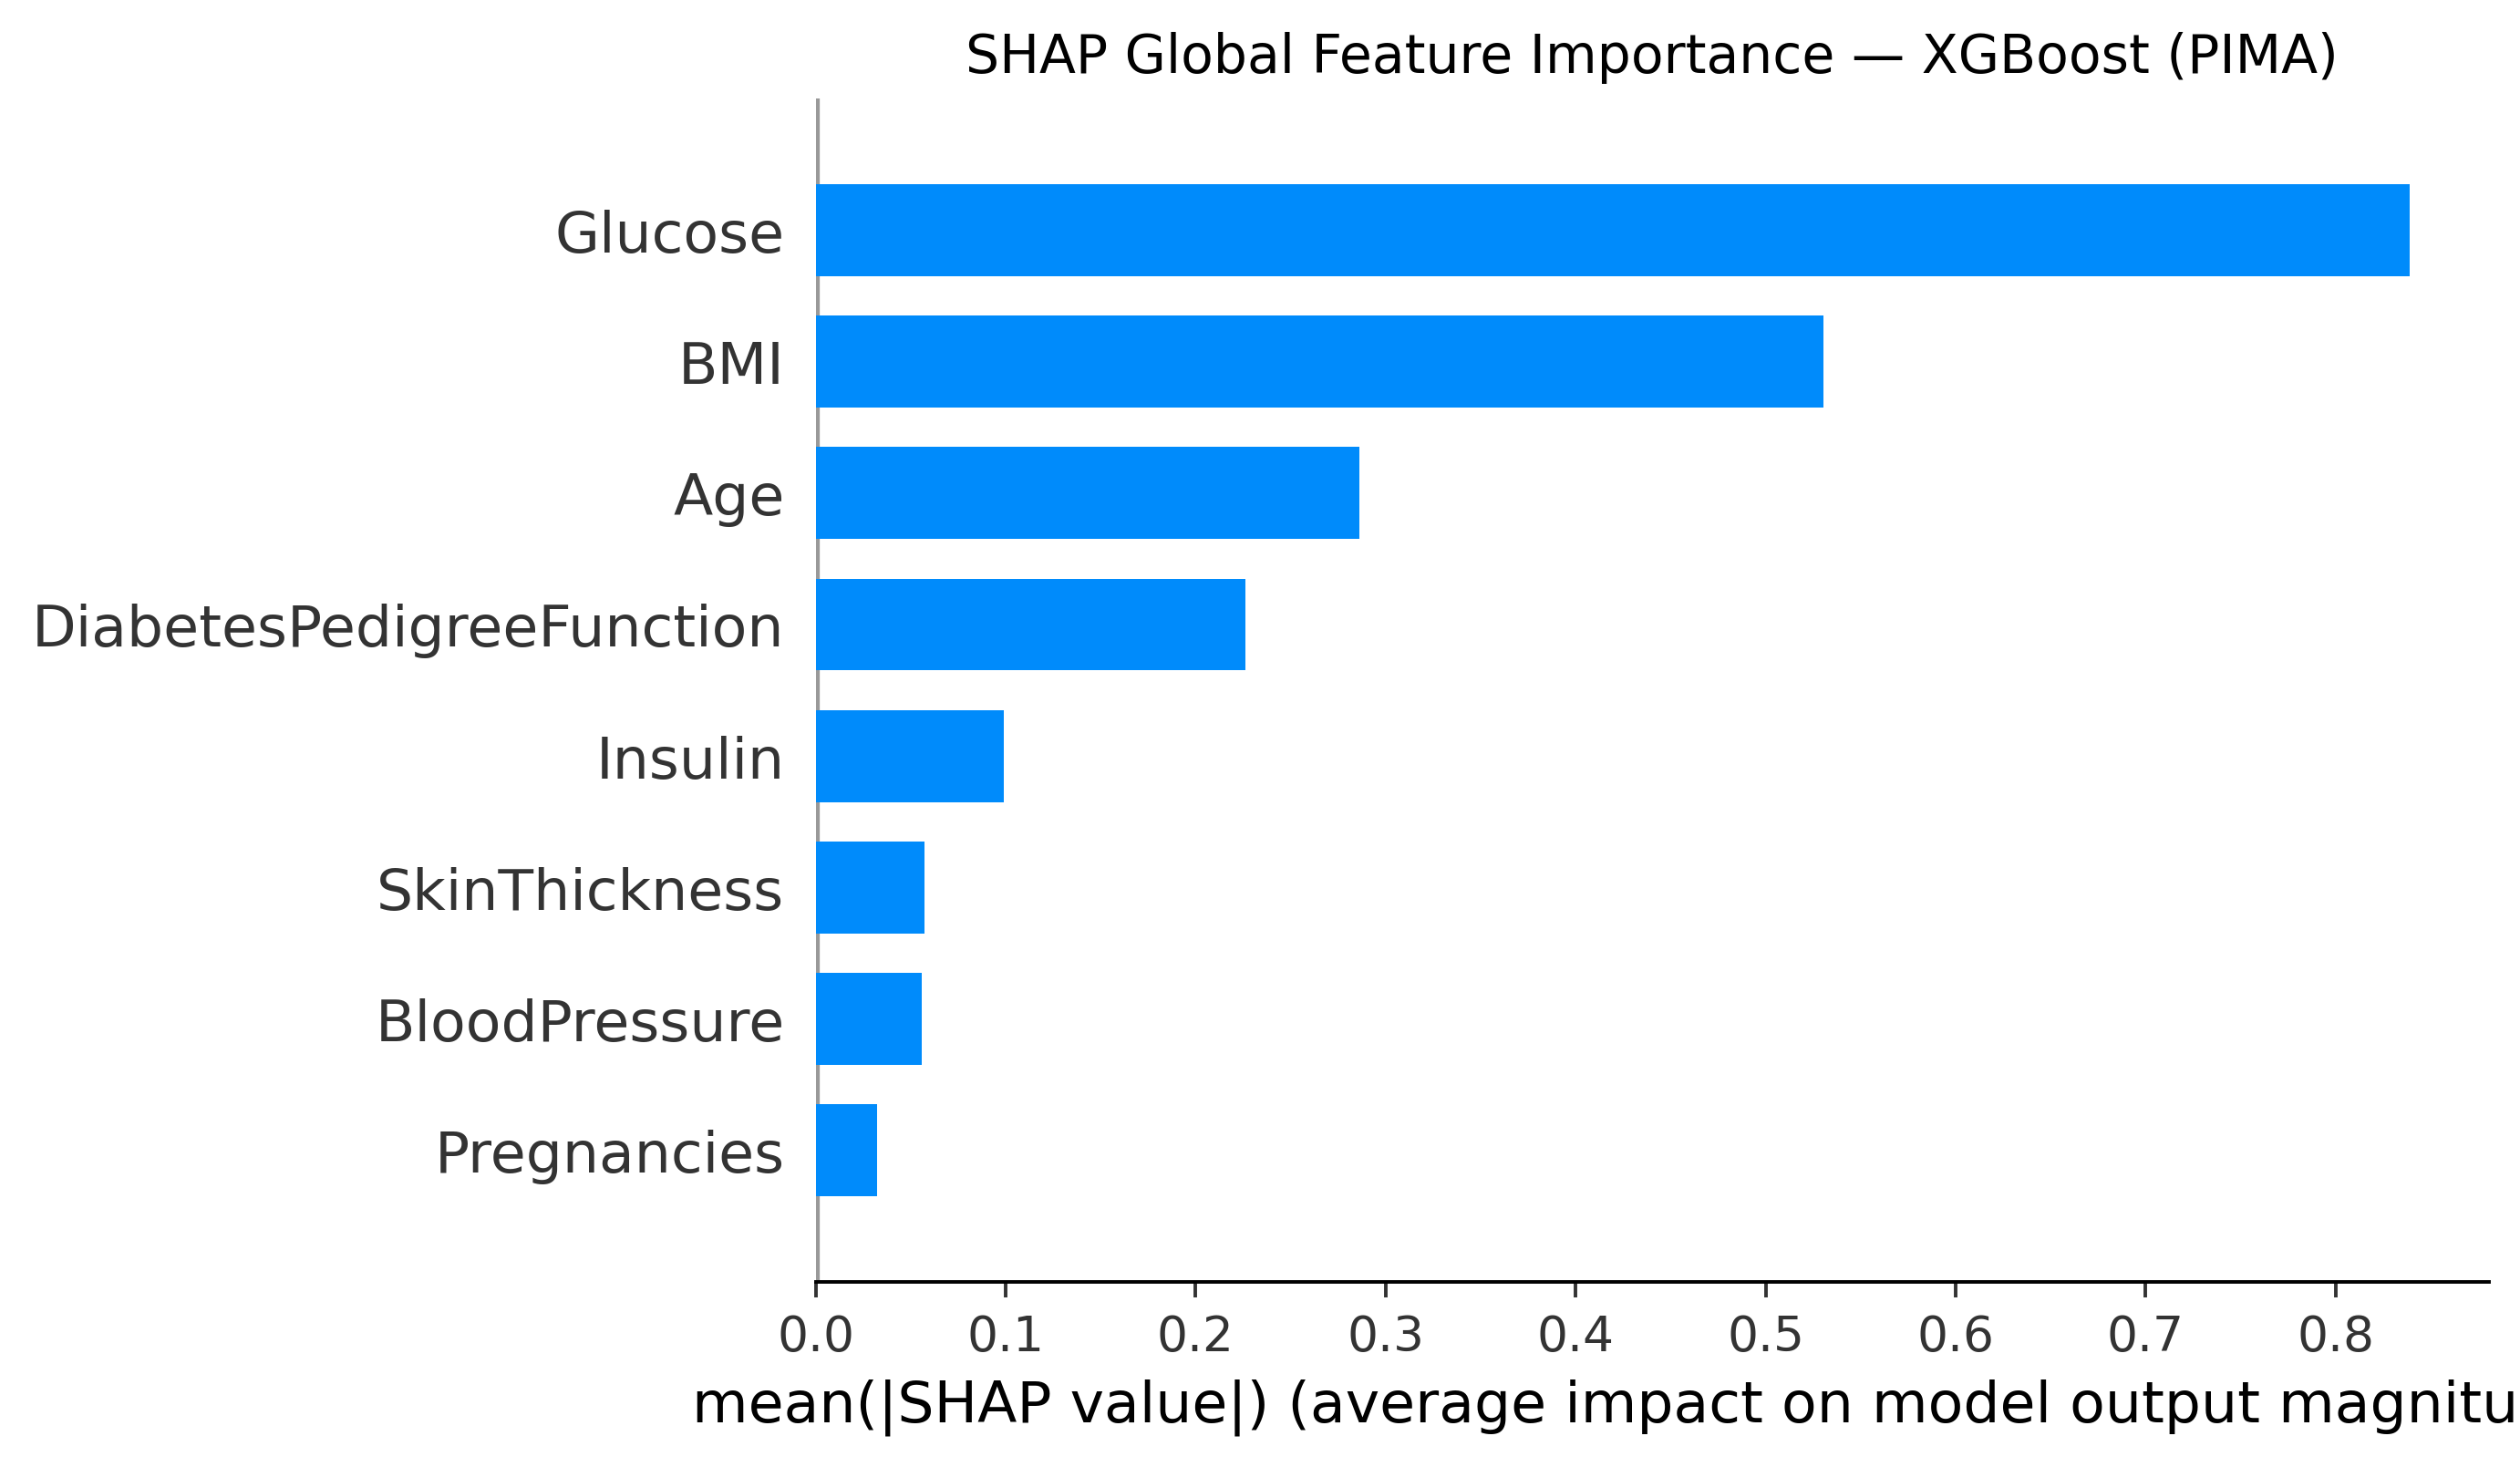

SHAP global bar plot saved.


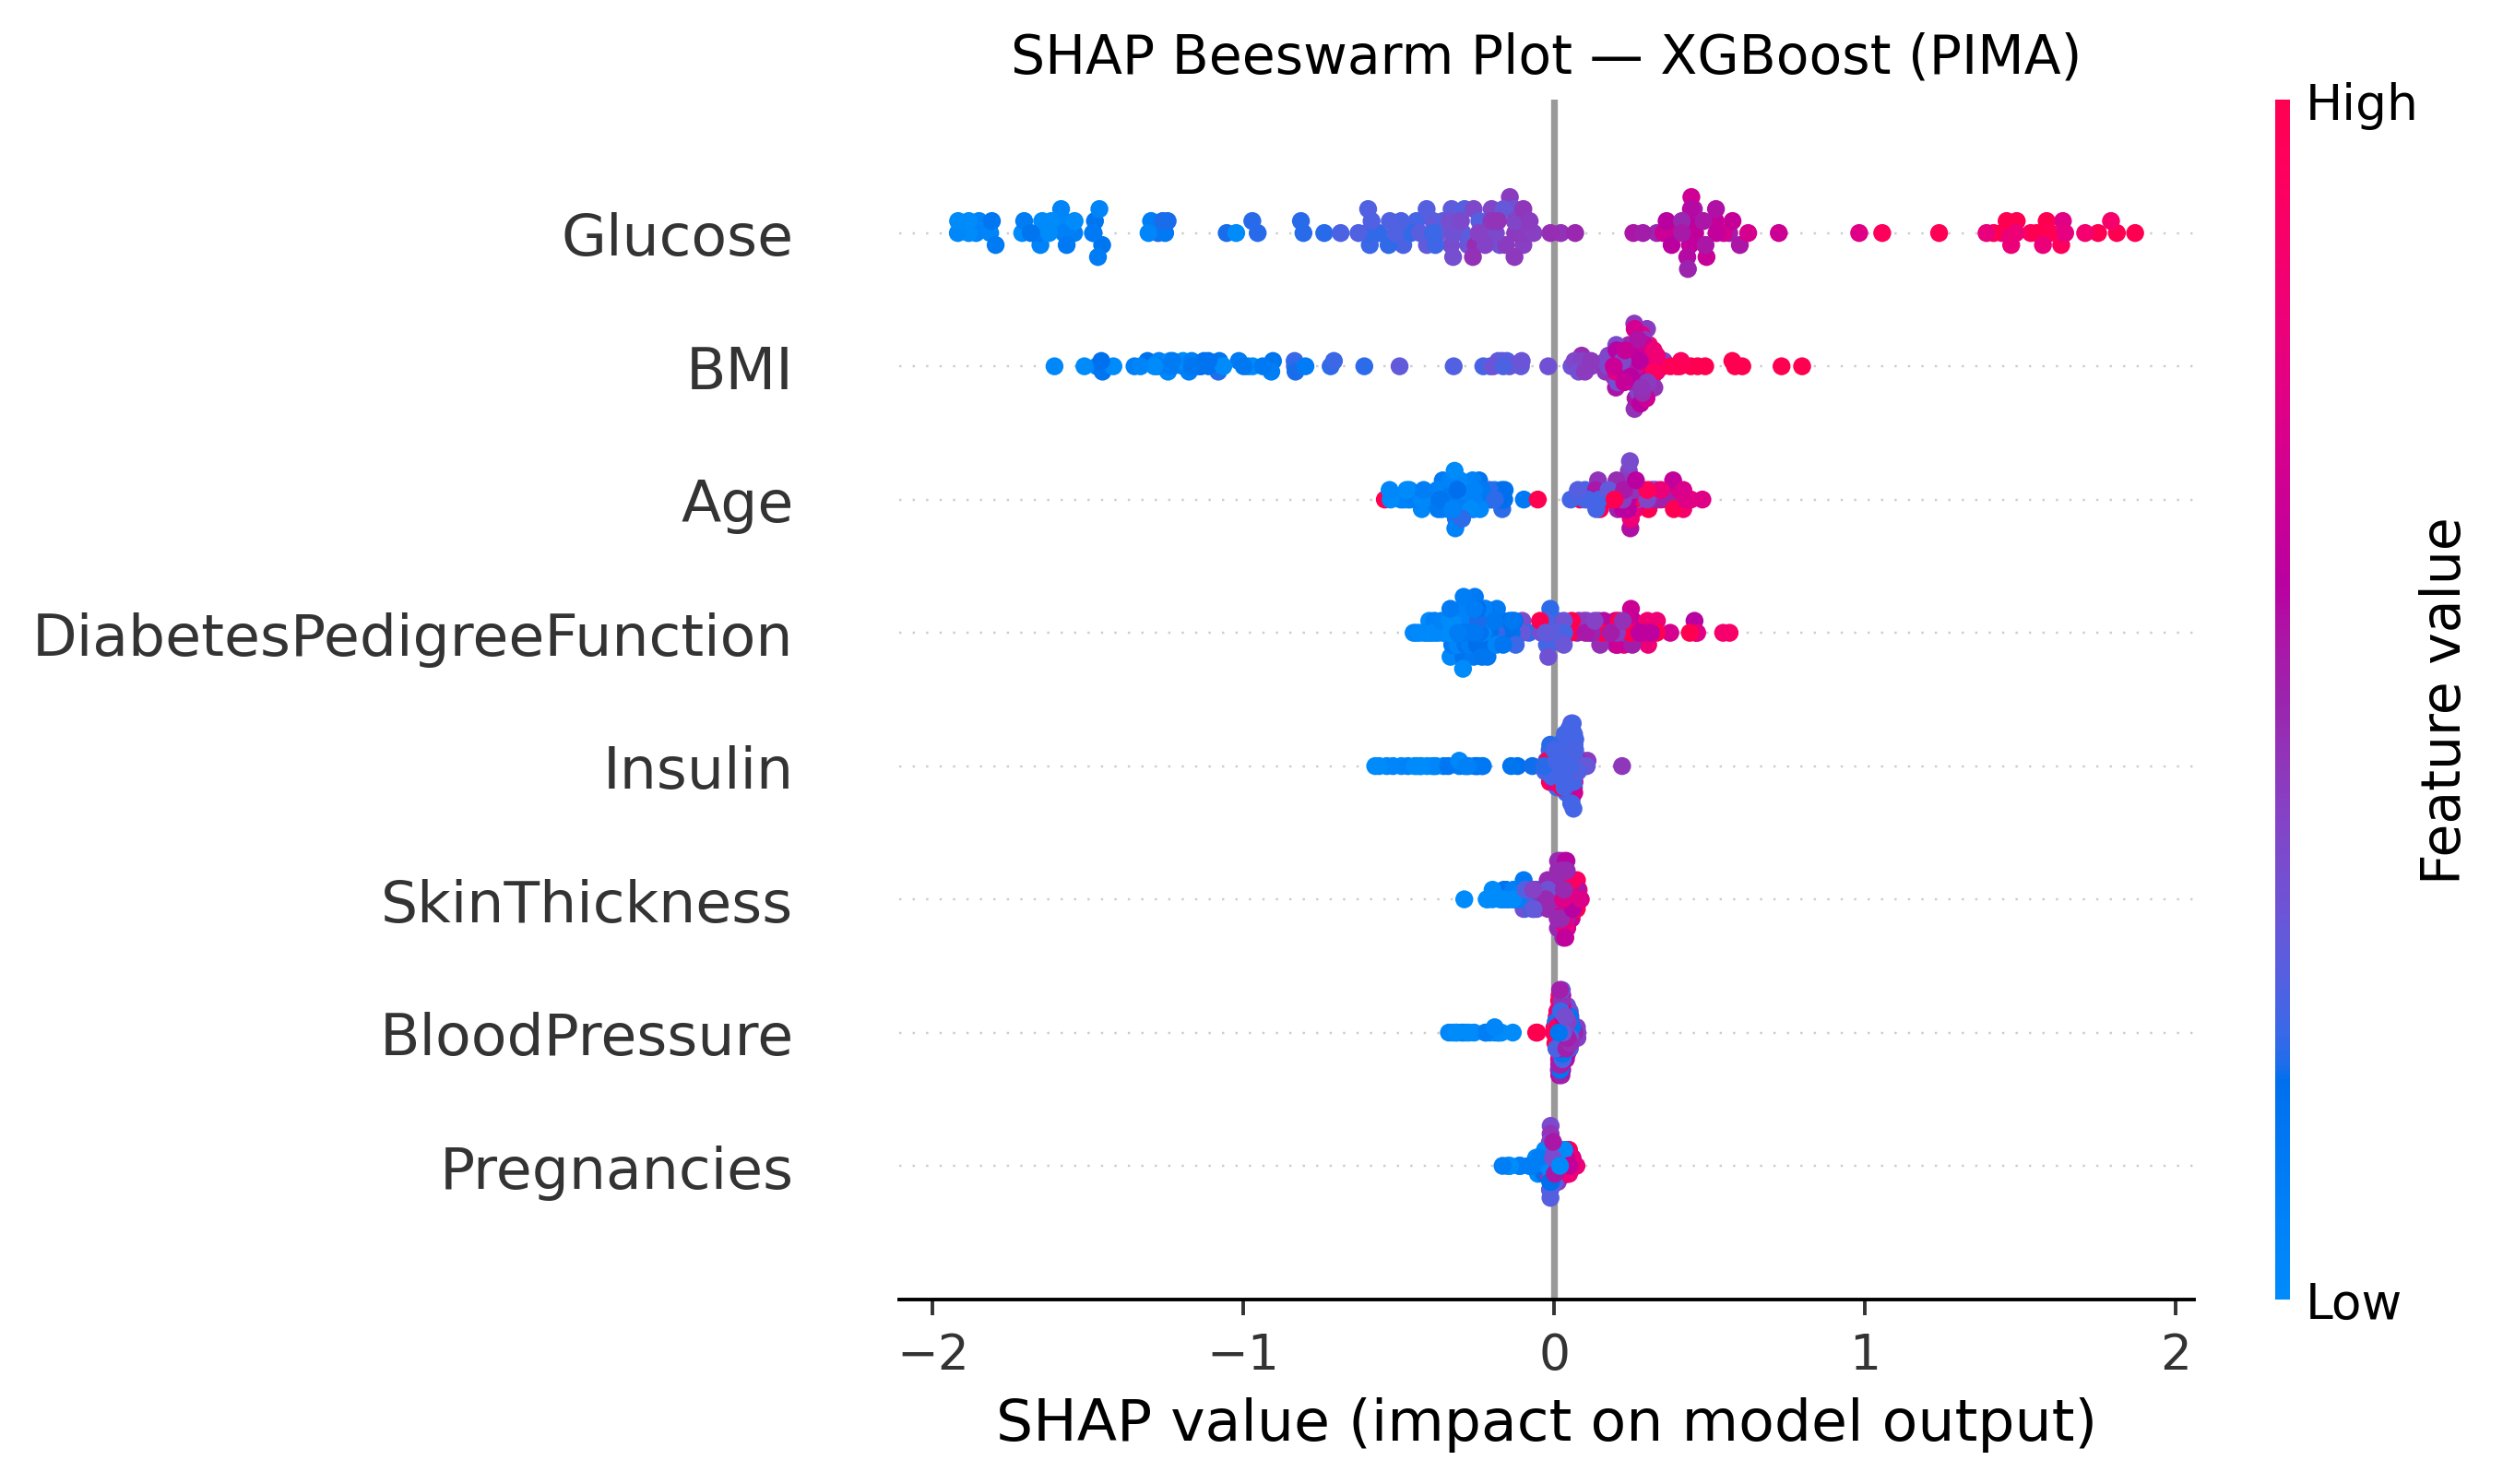

SHAP beeswarm plot saved.


In [ ]:
# CELL 14 — SHAP STAGE 1: GLOBAL FEATURE IMPORTANCE ON PIMA

# Extract XGBoost model and scaler from the tuned pipeline
xgb_model_pima = best_xgb_pima.named_steps['xgb']
scaler_pipeline_pima = best_xgb_pima.named_steps['scaler']

# Transform test data using pipeline's scaler
X_test_pima_pipeline_scaled = scaler_pipeline_pima.transform(X_test_pima)

# Create SHAP TreeExplainer
explainer_pima = shap.TreeExplainer(xgb_model_pima)

# Calculate SHAP values on full test set
shap_values_pima = explainer_pima.shap_values(X_test_pima_pipeline_scaled)

print(f"SHAP values calculated successfully.")
print(f"Shape: {shap_values_pima.shape}")

# Global feature importance — mean absolute SHAP values
mean_shap_global = np.abs(shap_values_pima).mean(axis=0)
global_importance = pd.Series(mean_shap_global,
                               index=feature_names_pima).sort_values(ascending=False)

print("\n=== Global Feature Importance (Full Test Set) ===")
print(global_importance)

# Plot 1 — SHAP Summary Bar Plot
plt.figure()
shap.summary_plot(shap_values_pima,
                  X_test_pima_pipeline_scaled,
                  feature_names=feature_names_pima,
                  plot_type='bar',
                  show=False)
plt.title('SHAP Global Feature Importance — XGBoost (PIMA)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/shap_global_bar_pima.png',
            dpi=350, bbox_inches='tight')
plt.show()
print("SHAP global bar plot saved.")

# Plot 2 — SHAP Beeswarm Plot
plt.figure()
shap.summary_plot(shap_values_pima,
                  X_test_pima_pipeline_scaled,
                  feature_names=feature_names_pima,
                  show=False)
plt.title('SHAP Beeswarm Plot — XGBoost (PIMA)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/shap_beeswarm_pima.png',
            dpi=350, bbox_inches='tight')
plt.show()
print("SHAP beeswarm plot saved.")

Minority class samples in test set: 54
SHAP values shape (minority): (54, 8)

=== Feature Importance — Minority Class (Diabetic) Only ===
Glucose                     0.693728
BMI                         0.366097
Age                         0.261391
DiabetesPedigreeFunction    0.205479
Insulin                     0.085425
BloodPressure               0.052030
SkinThickness               0.042716
Pregnancies                 0.032793
dtype: float32

=== Feature Importance — Full Test Set (Global) ===
Glucose                     0.838812
BMI                         0.530606
Age                         0.285979
DiabetesPedigreeFunction    0.226166
Insulin                     0.099171
SkinThickness               0.057136
BloodPressure               0.055761
Pregnancies                 0.032571
dtype: float32

=== Ranking Comparison: Global vs Minority Class ===
 Global Rank           Global Feature  Minority Rank         Minority Feature  Global SHAP  Minority SHAP  SHAP Drop (%)
           1

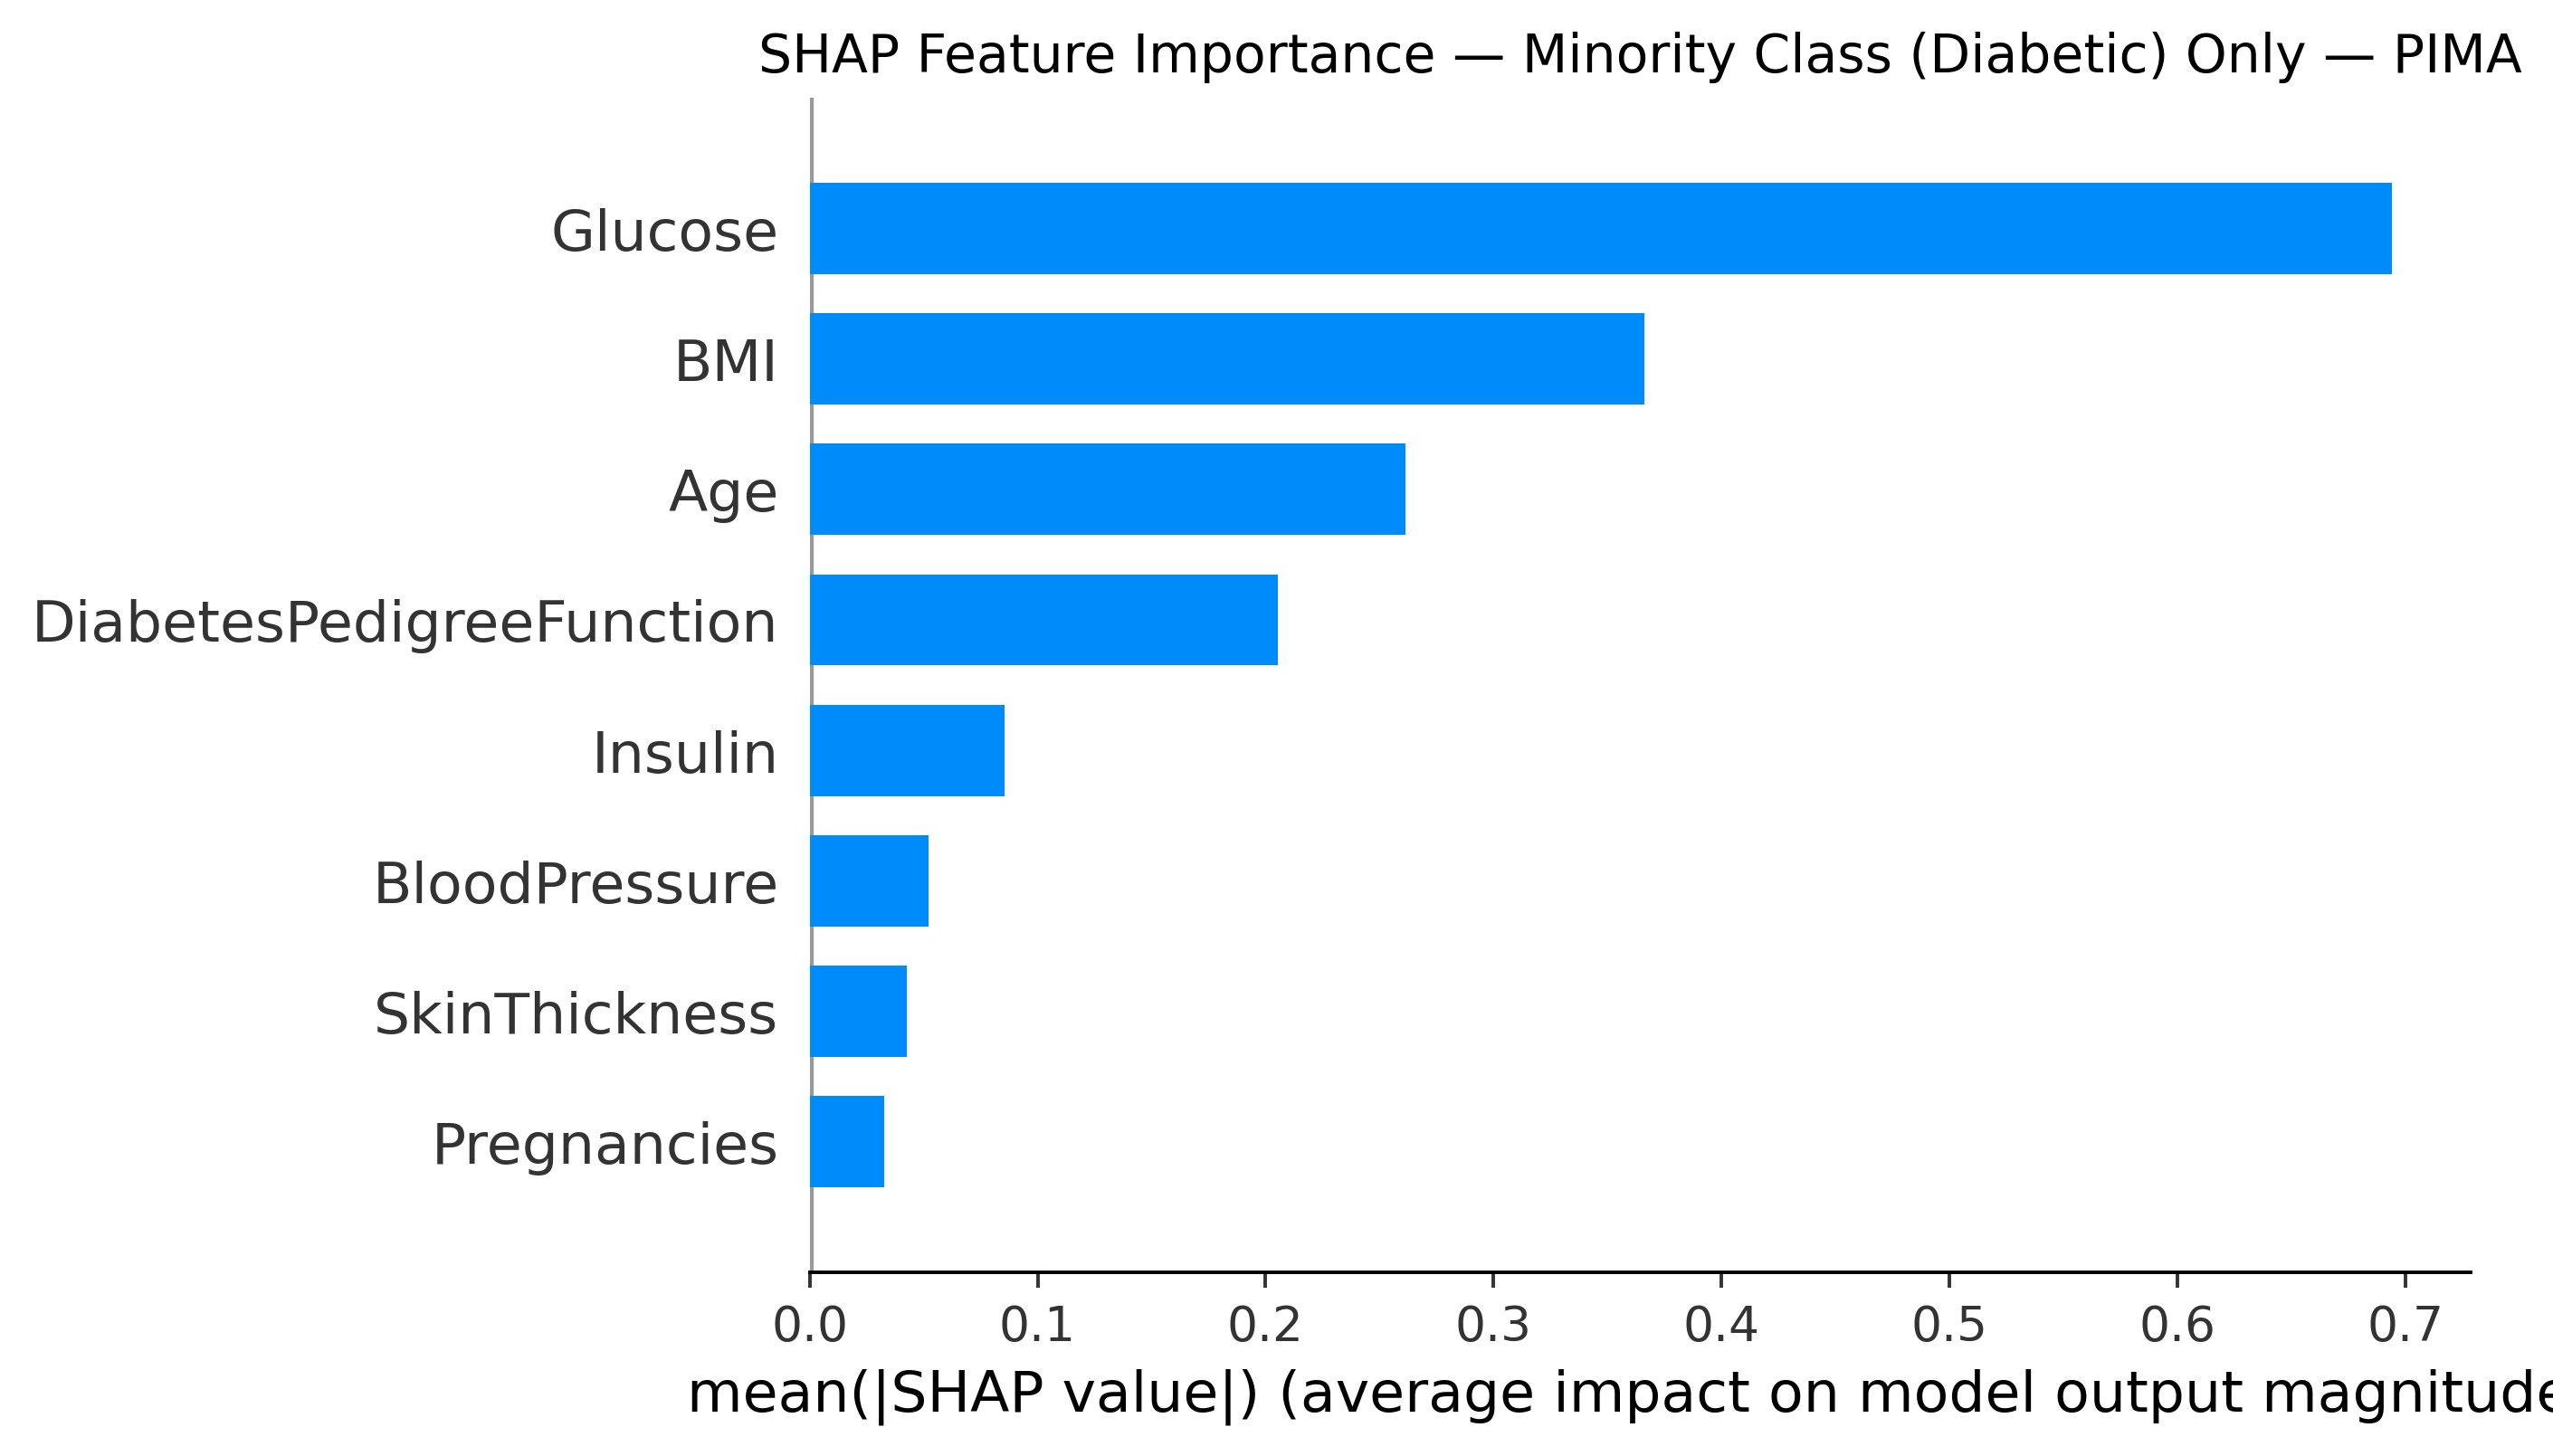

Minority class SHAP plot saved.


In [ ]:
# CELL 15 — SHAP ON MINORITY CLASS ONLY (PIMA)

# Filter test set to minority class only (Outcome = 1)
minority_mask_pima = y_test_pima.values == 1
X_test_pima_minority = X_test_pima_pipeline_scaled[minority_mask_pima]

print(f"Minority class samples in test set: {X_test_pima_minority.shape[0]}")

# Calculate SHAP values on minority class only
shap_values_minority_pima = explainer_pima.shap_values(X_test_pima_minority)
print(f"SHAP values shape (minority): {shap_values_minority_pima.shape}")

# Mean absolute SHAP values for minority class
mean_shap_minority = np.abs(shap_values_minority_pima).mean(axis=0)
minority_importance = pd.Series(mean_shap_minority,
                                 index=feature_names_pima).sort_values(ascending=False)

print("\n=== Feature Importance — Minority Class (Diabetic) Only ===")
print(minority_importance)

print("\n=== Feature Importance — Full Test Set (Global) ===")
print(global_importance)

# Compare rankings
print("\n=== Ranking Comparison: Global vs Minority Class ===")
global_rank = list(global_importance.index)
minority_rank = list(minority_importance.index)

comparison_df = pd.DataFrame({
    'Global Rank': range(1, 9),
    'Global Feature': global_rank,
    'Minority Rank': [minority_rank.index(f) + 1 for f in global_rank],
    'Minority Feature': [minority_rank[i] for i in range(8)],
    'Global SHAP': [global_importance[f] for f in global_rank],
    'Minority SHAP': [minority_importance[f] for f in global_rank],
    'SHAP Drop (%)': [((global_importance[f] - minority_importance[f]) /
                        global_importance[f] * 100) for f in global_rank]
})
print(comparison_df.to_string(index=False))

# Plot — minority class SHAP bar
plt.figure()
shap.summary_plot(shap_values_minority_pima,
                  X_test_pima_minority,
                  feature_names=feature_names_pima,
                  plot_type='bar',
                  show=False)
plt.title('SHAP Feature Importance — Minority Class (Diabetic) Only — PIMA')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/shap_minority_bar_pima.png',
            dpi=350, bbox_inches='tight')
plt.show()
print("Minority class SHAP plot saved.")

In [ ]:
# CELL 16 — STANDARD LIME ON MINORITY CLASS (PIMA)

# Top 5 SHAP features locked in as Stage 2 anchors
top5_features_pima = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction', 'Insulin']
top5_indices_pima = [feature_names_pima.index(f) for f in top5_features_pima]

print(f"Stage 2 Anchor Features: {top5_features_pima}")

# Create LIME explainer
lime_explainer_pima = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_pima_scaled,
    feature_names=feature_names_pima,
    class_names=['Non-Diabetic', 'Diabetic'],
    mode='classification',
    random_state=42
)

# Define predict function using pipeline's XGBoost model
def predict_fn_pima(x):
    return xgb_model_pima.predict_proba(x)

# Select first 5 minority class samples
minority_indices_pima = np.where(y_test_pima.values == 1)[0]
selected_minority_pima = minority_indices_pima[:5]

print("\n=== Standard LIME — Top Features per Minority Class Sample ===\n")

standard_lime_results_pima = {}

for i, idx in enumerate(selected_minority_pima):
    sample = X_test_pima_pipeline_scaled[idx]
    exp = lime_explainer_pima.explain_instance(
        sample,
        predict_fn_pima,
        num_features=8,
        num_samples=1000
    )

    weights = dict(exp.as_list())
    standard_lime_results_pima[idx] = weights

    # Extract feature names from LIME conditions
    top_features = []
    for feat_condition in list(weights.keys())[:5]:
        for feat in feature_names_pima:
            if feat in feat_condition:
                top_features.append(feat)
                break

    print(f"Sample {i+1} (test index {idx}):")
    print(f"  Top 5 features: {top_features}")
    for feat_condition, weight in sorted(weights.items(),
                                          key=lambda x: abs(x[1]),
                                          reverse=True)[:5]:
        print(f"    {feat_condition}: {weight:.4f}")
    print()

print("Standard LIME complete.")

Stage 2 Anchor Features: ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction', 'Insulin']

=== Standard LIME — Top Features per Minority Class Sample ===

Sample 1 (test index 3):
  Top 5 features: ['BMI', 'Insulin', 'DiabetesPedigreeFunction', 'Age', 'Glucose']
    BMI <= -0.67: -0.2746
    Insulin <= -0.22: -0.1015
    DiabetesPedigreeFunction > 0.49: 0.0891
    -0.26 < Age <= 0.63: 0.0729
    -0.75 < Glucose <= -0.18: -0.0656

Sample 2 (test index 6):
  Top 5 features: ['BMI', 'DiabetesPedigreeFunction', 'Age', 'Glucose', 'Insulin']
    BMI > 0.60: 0.1496
    DiabetesPedigreeFunction <= -0.72: -0.0893
    Age > 0.63: 0.0837
    -0.75 < Glucose <= -0.18: -0.0706
    Insulin <= -0.22: -0.0383

Sample 3 (test index 7):
  Top 5 features: ['Glucose', 'BMI', 'DiabetesPedigreeFunction', 'Insulin', 'Age']
    Glucose > 0.67: 0.3510
    BMI <= -0.67: -0.2462
    DiabetesPedigreeFunction > 0.49: 0.0911
    Insulin <= -0.22: -0.0737
    -0.26 < Age <= 0.63: 0.0719

Sample 4 (test index 11):
  

In [ ]:
# CELL 17 — SHAP-ANCHORED LIME ON MINORITY CLASS (PIMA)

import time

print("=== SHAP-Anchored LIME — Minority Class (PIMA) ===\n")
print(f"Anchor features: {top5_features_pima}\n")

anchored_lime_results_pima = {}
consistency_scores = []
lime_times_standard = []
lime_times_anchored = []

for i, idx in enumerate(selected_minority_pima):
    sample = X_test_pima_pipeline_scaled[idx]

    # --- Standard LIME timing ---
    t0 = time.time()
    exp_standard = lime_explainer_pima.explain_instance(
        sample, predict_fn_pima,
        num_features=8, num_samples=1000
    )
    t1 = time.time()
    lime_times_standard.append(t1 - t0)

    # --- SHAP-Anchored LIME timing ---
    t2 = time.time()
    exp_anchored = lime_explainer_pima.explain_instance(
        sample, predict_fn_pima,
        num_features=5, num_samples=1000
    )
    t3 = time.time()
    lime_times_anchored.append(t3 - t2)

    # Get anchored weights filtered to top 5 SHAP features
    all_weights = dict(exp_anchored.as_list())
    anchored_weights = {}
    for feat_condition, weight in all_weights.items():
        for anchor_feat in top5_features_pima:
            if anchor_feat in feat_condition:
                anchored_weights[anchor_feat] = weight
                break

    anchored_lime_results_pima[idx] = anchored_weights

    # Standard LIME top 5 features
    standard_top5 = set()
    for feat_condition in list(standard_lime_results_pima[idx].keys())[:5]:
        for feat in feature_names_pima:
            if feat in feat_condition:
                standard_top5.add(feat)
                break

    # Consistency score
    overlap = len(set(top5_features_pima) & standard_top5)
    consistency_scores.append(overlap / 5)

    print(f"Sample {i+1} (test index {idx}):")
    print(f"  Standard LIME top 5:     {sorted(standard_top5)}")
    print(f"  SHAP-Anchored top 5:     {sorted(top5_features_pima)}")
    print(f"  Overlap: {overlap}/5 ({overlap/5*100:.0f}%)")
    print(f"  Anchored LIME weights:")
    for feat in top5_features_pima:
        weight = anchored_weights.get(feat, 'not captured')
        print(f"    {feat}: {weight}")
    print()

print(f"=== Consistency Score ===")
print(f"Mean overlap: {np.mean(consistency_scores):.2f} "
      f"({np.mean(consistency_scores)*100:.0f}%)")

print(f"\n=== Latency Comparison ===")
print(f"Standard LIME — mean time: {np.mean(lime_times_standard):.3f}s")
print(f"Anchored LIME  — mean time: {np.mean(lime_times_anchored):.3f}s")
print(f"Latency reduction: "
      f"{((np.mean(lime_times_standard) - np.mean(lime_times_anchored)) / np.mean(lime_times_standard) * 100):.1f}%")

=== SHAP-Anchored LIME — Minority Class (PIMA) ===

Anchor features: ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction', 'Insulin']

Sample 1 (test index 3):
  Standard LIME top 5:     ['Age', 'BMI', 'DiabetesPedigreeFunction', 'Glucose', 'Insulin']
  SHAP-Anchored top 5:     ['Age', 'BMI', 'DiabetesPedigreeFunction', 'Glucose', 'Insulin']
  Overlap: 5/5 (100%)
  Anchored LIME weights:
    Glucose: -0.07168070580875079
    BMI: -0.25665578125160066
    Age: 0.04857810902940887
    DiabetesPedigreeFunction: 0.1065407229913838
    Insulin: -0.04698172313445416

Sample 2 (test index 6):
  Standard LIME top 5:     ['Age', 'BMI', 'DiabetesPedigreeFunction', 'Glucose', 'Insulin']
  SHAP-Anchored top 5:     ['Age', 'BMI', 'DiabetesPedigreeFunction', 'Glucose', 'Insulin']
  Overlap: 5/5 (100%)
  Anchored LIME weights:
    Glucose: -0.052961598438521634
    BMI: 0.12844074299891162
    Age: 0.05914560406743473
    DiabetesPedigreeFunction: -0.0942055262107768
    Insulin: -0.05088846835523070

In [ ]:
# CELL 18 — DICE COUNTERFACTUALS WITH CLINICAL CONSTRAINTS (PIMA)
import dice_ml
from dice_ml import Dice

# Prepare training data for DiCE
X_train_dice_pima = pd.DataFrame(
    X_train_pima_scaled,
    columns=feature_names_pima
)
y_train_dice_pima = pd.Series(y_train_pima_smote.values)

train_df_dice_pima = X_train_dice_pima.copy()
train_df_dice_pima['Outcome'] = y_train_dice_pima.values

# Create DiCE data object
d_pima = dice_ml.Data(
    dataframe=train_df_dice_pima,
    continuous_features=feature_names_pima,
    outcome_name='Outcome'
)

# Create DiCE model object
m_pima = dice_ml.Model(
    model=xgb_model_pima,
    backend='sklearn'
)

# Create DiCE explainer
dice_exp_pima = Dice(d_pima, m_pima, method='random')

print("DiCE explainer created successfully.")

# Find misclassified minority class samples
misclassified_pima = []
for idx in minority_indices_pima:
    sample = X_test_pima_pipeline_scaled[idx].reshape(1, -1)
    pred = xgb_model_pima.predict(sample)[0]
    true = y_test_pima.values[idx]
    if pred != true:
        misclassified_pima.append(idx)

print(f"Misclassified minority samples found: {len(misclassified_pima)}")
print(f"Using first 3: {misclassified_pima[:3]}")

# Features that CAN be changed — Age and DiabetesPedigreeFunction locked
actionable_features = ['Glucose', 'BMI', 'Insulin',
                        'BloodPressure', 'SkinThickness', 'Pregnancies']

print(f"\nActionable features: {actionable_features}")
print(f"Locked (immutable): ['Age', 'DiabetesPedigreeFunction']")

# Generate counterfactuals for first 3 misclassified minority samples
print("\n" + "="*60)

for i, idx in enumerate(misclassified_pima[:3]):
    sample_df = pd.DataFrame(
        X_test_pima_pipeline_scaled[idx].reshape(1, -1),
        columns=feature_names_pima
    )

    print(f"\n=== Counterfactuals for Sample {i+1} (test index {idx}) ===")
    print(f"True label: Diabetic (1)")
    print(f"Model prediction: Non-Diabetic (0) — missed diagnosis")

    try:
        dice_result = dice_exp_pima.generate_counterfactuals(
            sample_df,
            total_CFs=3,
            desired_class='opposite',
            features_to_vary=actionable_features
        )
        print(dice_result.cf_examples_list[0].final_cfs_df)
    except Exception as e:
        print(f"Could not generate counterfactuals: {e}")

print("\nDiCE generation complete.")

DiCE explainer created successfully.
Misclassified minority samples found: 8
Using first 3: [np.int64(14), np.int64(35), np.int64(46)]

Actionable features: ['Glucose', 'BMI', 'Insulin', 'BloodPressure', 'SkinThickness', 'Pregnancies']
Locked (immutable): ['Age', 'DiabetesPedigreeFunction']


=== Counterfactuals for Sample 1 (test index 14) ===
True label: Diabetic (1)
Model prediction: Non-Diabetic (0) — missed diagnosis


100%|██████████| 1/1 [00:33<00:00, 33.80s/it]


   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0    -0.277699  0.785361      -1.657859      -0.071265 -0.216845  0.421886   
1    -0.772006 -0.167764      -1.766949      -0.071265 -0.216845  4.778802   
2    -0.277699  0.955642      -1.766949      -0.071265 -0.216845  0.421886   

   DiabetesPedigreeFunction       Age  Outcome  
0                 -1.124146 -0.789049        1  
1                 -1.124146 -0.789049        1  
2                 -1.124146 -0.789049        1  

=== Counterfactuals for Sample 2 (test index 35) ===
True label: Diabetic (1)
Model prediction: Non-Diabetic (0) — missed diagnosis


100%|██████████| 1/1 [00:32<00:00, 32.98s/it]


   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0    -1.196978  0.447668       0.267323       6.457595 -0.216845  0.017348   
1    -1.196978 -0.428357       0.267323      -0.071265 -0.216845  4.861421   
2    -1.196978 -0.428357       0.325582      -0.071265 -0.216845  3.696841   

   DiabetesPedigreeFunction       Age  Outcome  
0                 -0.653036 -0.966363        1  
1                 -0.653036 -0.966363        1  
2                 -0.653036 -0.966363        1  

=== Counterfactuals for Sample 3 (test index 46) ===
True label: Diabetic (1)
Model prediction: Non-Diabetic (0) — missed diagnosis


100%|██████████| 1/1 [00:00<00:00,  6.99it/s]

   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.948006  1.806097       0.328457      -0.666983 -0.216845 -1.001490   
1     1.759805 -0.656376      -1.088858      -0.666983 -0.216845  2.890297   
2     0.948006  1.926916      -1.088858      -0.422179 -0.216845 -1.001490   

   DiabetesPedigreeFunction      Age  Outcome  
0                 -0.596878 -0.43442        1  
1                 -0.596878 -0.43442        1  
2                 -0.596878 -0.43442        1  

DiCE generation complete.


In [ ]:
# CELL 19 — INVERSE TRANSFORM + PLAIN LANGUAGE OUTPUT (PIMA)

def inverse_transform_sample(scaled_values, scaler, feature_names):
    df_scaled = pd.DataFrame([scaled_values], columns=feature_names)
    df_original = pd.DataFrame(
        scaler.inverse_transform(df_scaled),
        columns=feature_names
    )
    return df_original.round(1)

def generate_plain_language(original_df, cf_df, actionable_features):
    actions = []
    for feat in actionable_features:
        orig_val = original_df[feat].values[0]
        cf_val = cf_df[feat].values[0]
        diff = cf_val - orig_val
        if abs(diff) > 0.5:
            if diff < 0:
                actions.append(
                    f"Reduce {feat} from {orig_val:.1f} to {cf_val:.1f}"
                )
            else:
                actions.append(
                    f"Increase {feat} from {orig_val:.1f} to {cf_val:.1f}"
                )
    if not actions:
        actions.append("Minimal changes required — borderline case")
    return actions

print("=" * 60)
print("DICE COUNTERFACTUALS — ORIGINAL CLINICAL UNITS (PIMA)")
print("=" * 60)

# DiCE results in scaled form for each sample
dice_scaled_results = {
    misclassified_pima[0]: {
        'original': X_test_pima_pipeline_scaled[misclassified_pima[0]],
        'cfs': [
            [-0.277699, 2.345242, -1.766949, -0.071265, -0.216845, 0.421886, -1.124146, -0.789049],
            [-0.277699, -0.167764, -1.766949, 5.883782, -0.216845, 3.059701, -1.124146, -0.789049],
            [-0.277699, 1.189814, -1.766949, -0.071265, -0.216845, 0.421886, -1.124146, -0.789049]
        ]
    },
    misclassified_pima[1]: {
        'original': X_test_pima_pipeline_scaled[misclassified_pima[1]],
        'cfs': [
            [-1.196978, -0.428357, 0.267323, 2.064573, -0.216845, 4.268648, -0.653036, -0.966363],
            [-1.196978, 1.673839, 0.267323, 0.449501, -0.216845, 0.017348, -0.653036, -0.966363],
            [-1.196978, 1.288128, 3.903838, -0.071265, -0.216845, 0.017348, -0.653036, -0.966363]
        ]
    },
    misclassified_pima[2]: {
        'original': X_test_pima_pipeline_scaled[misclassified_pima[2]],
        'cfs': [
            [0.948006, 1.138808, -1.088858, 0.464915, -0.216845, -1.00149, -0.596878, -0.43442],
            [1.617161, 1.973493, -1.088858, -0.666983, -0.216845, -1.00149, -0.596878, -0.43442],
            [0.948006, 0.975944, -1.088858, -0.666983, 0.243090, -1.00149, -0.596878, -0.43442]
        ]
    }
}

for i, (idx, data) in enumerate(dice_scaled_results.items()):
    print(f"\n--- Patient {i+1} (test index {idx}) ---")

    original_clinical = inverse_transform_sample(
        data['original'], scaler_pima, feature_names_pima
    )
    print("Original patient values:")
    print(original_clinical.to_string(index=False))

    for j, cf_scaled in enumerate(data['cfs']):
        cf_clinical = inverse_transform_sample(
            cf_scaled, scaler_pima, feature_names_pima
        )
        actions = generate_plain_language(
            original_clinical, cf_clinical, actionable_features
        )
        print(f"\n  Counterfactual {j+1} — Action Plan:")
        for action in actions:
            print(f"    • {action}")

print("\n" + "="*60)
print("Plain language output complete.")

DICE COUNTERFACTUALS — ORIGINAL CLINICAL UNITS (PIMA)

--- Patient 1 (test index 14) ---
Original patient values:
 Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI  DiabetesPedigreeFunction  Age
         3.0    121.0           52.0           29.0    125.0 36.0                       0.1 25.0

  Counterfactual 1 — Action Plan:
    • Increase Glucose from 121.0 to 198.1

  Counterfactual 2 — Action Plan:
    • Increase BMI from 36.0 to 53.6
    • Increase SkinThickness from 29.0 to 79.0

  Counterfactual 3 — Action Plan:
    • Increase Glucose from 121.0 to 162.7

--- Patient 2 (test index 35) ---
Original patient values:
 Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI  DiabetesPedigreeFunction  Age
         0.0    113.0           76.0           29.0    125.0 33.3                       0.3 23.0

  Counterfactual 1 — Action Plan:
    • Increase BMI from 33.3 to 61.7
    • Increase SkinThickness from 29.0 to 46.9

  Counterfactual 2 — Action Plan:
    • Inc

In [ ]:
# CELL 20 — XGBOOST BASELINE ON CDC
xgb_baseline_cdc = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_baseline_cdc.fit(X_train_cdc_scaled, y_train_cdc_smote)

# Predictions
y_pred_xgb_base_cdc = xgb_baseline_cdc.predict(X_test_cdc_scaled)
y_proba_xgb_base_cdc = xgb_baseline_cdc.predict_proba(X_test_cdc_scaled)[:, 1]

print("=== XGBoost Baseline — CDC ===")
print(f"Accuracy:  {accuracy_score(y_test_cdc, y_pred_xgb_base_cdc):.4f}")
print(f"Precision: {precision_score(y_test_cdc, y_pred_xgb_base_cdc):.4f}")
print(f"Recall:    {recall_score(y_test_cdc, y_pred_xgb_base_cdc):.4f}")
print(f"F1-score:  {f1_score(y_test_cdc, y_pred_xgb_base_cdc):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test_cdc, y_proba_xgb_base_cdc):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test_cdc, y_pred_xgb_base_cdc,
      target_names=['Non-Diabetic (0)', 'Diabetic (1)']))

=== XGBoost Baseline — CDC ===
Accuracy:  0.7243
Precision: 0.2887
Recall:    0.6687
F1-score:  0.4033
AUC-ROC:   0.7755

=== Classification Report ===
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.93      0.73      0.82     43667
    Diabetic (1)       0.29      0.67      0.40      7069

        accuracy                           0.72     50736
       macro avg       0.61      0.70      0.61     50736
    weighted avg       0.84      0.72      0.76     50736



In [ ]:
# CELL 21 — XGBOOST TUNED (CORRECTED PIPELINE) ON CDC
pipeline_cdc = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(random_state=42, eval_metric='logloss'))
])

param_dist_cdc = {
    'xgb__n_estimators': [100, 200, 300, 400],
    'xgb__max_depth': [3, 4, 5, 6, 7],
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'xgb__subsample': [0.7, 0.8, 0.9, 1.0],
    'xgb__scale_pos_weight': [1, 1.5, 2]
}

xgb_search_cdc = RandomizedSearchCV(
    pipeline_cdc,
    param_distributions=param_dist_cdc,
    n_iter=30,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1
)

xgb_search_cdc.fit(X_train_cdc, y_train_cdc)

print("=== Best Parameters (CDC) ===")
print(xgb_search_cdc.best_params_)
print(f"\nBest CV F1 (corrected): {xgb_search_cdc.best_score_:.4f}")

best_xgb_cdc = xgb_search_cdc.best_estimator_
y_pred_xgb_tuned_cdc = best_xgb_cdc.predict(X_test_cdc)
y_proba_xgb_tuned_cdc = best_xgb_cdc.predict_proba(X_test_cdc)[:, 1]

print("\n=== XGBoost Tuned — CDC ===")
print(f"Accuracy:  {accuracy_score(y_test_cdc, y_pred_xgb_tuned_cdc):.4f}")
print(f"Precision: {precision_score(y_test_cdc, y_pred_xgb_tuned_cdc):.4f}")
print(f"Recall:    {recall_score(y_test_cdc, y_pred_xgb_tuned_cdc):.4f}")
print(f"F1-score:  {f1_score(y_test_cdc, y_pred_xgb_tuned_cdc):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test_cdc, y_proba_xgb_tuned_cdc):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test_cdc, y_pred_xgb_tuned_cdc,
      target_names=['Non-Diabetic (0)', 'Diabetic (1)']))

=== Best Parameters (CDC) ===
{'xgb__subsample': 0.9, 'xgb__scale_pos_weight': 1, 'xgb__n_estimators': 400, 'xgb__max_depth': 4, 'xgb__learning_rate': 0.01}

Best CV F1 (corrected): 0.4207

=== XGBoost Tuned — CDC ===
Accuracy:  0.7080
Precision: 0.2900
Recall:    0.7564
F1-score:  0.4193
AUC-ROC:   0.7970

=== Classification Report ===
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.95      0.70      0.81     43667
    Diabetic (1)       0.29      0.76      0.42      7069

        accuracy                           0.71     50736
       macro avg       0.62      0.73      0.61     50736
    weighted avg       0.86      0.71      0.75     50736



In [ ]:
# SAVE TRAINED PIPELINES TO GOOGLE DRIVE
import joblib

# Save PIMA tuned pipeline
joblib.dump(best_xgb_pima,
            '/content/drive/MyDrive/best_xgb_pima_pipeline.pkl')
print("PIMA pipeline saved.")

# Save CDC tuned pipeline
joblib.dump(best_xgb_cdc,
            '/content/drive/MyDrive/best_xgb_cdc_pipeline.pkl')
print("CDC pipeline saved.")

# Save scalers separately (needed for inverse transform)
joblib.dump(scaler_pima,
            '/content/drive/MyDrive/scaler_pima.pkl')
print("PIMA scaler saved.")

joblib.dump(scaler_cdc,
            '/content/drive/MyDrive/scaler_cdc.pkl')
print("CDC scaler saved.")

print("\nAll models and scalers saved to Google Drive successfully.")

PIMA pipeline saved.
CDC pipeline saved.
PIMA scaler saved.
CDC scaler saved.

All models and scalers saved to Google Drive successfully.


In [ ]:
# LOAD TRAINED PIPELINES FROM GOOGLE DRIVE
import joblib

# Load PIMA pipeline
best_xgb_pima = joblib.load(
    '/content/drive/MyDrive/best_xgb_pima_pipeline.pkl')
xgb_model_pima = best_xgb_pima.named_steps['xgb']
scaler_pipeline_pima = best_xgb_pima.named_steps['scaler']
print("PIMA pipeline loaded.")

# Load CDC pipeline
best_xgb_cdc = joblib.load(
    '/content/drive/MyDrive/best_xgb_cdc_pipeline.pkl')
xgb_model_cdc = best_xgb_cdc.named_steps['xgb']
scaler_pipeline_cdc = best_xgb_cdc.named_steps['scaler']
print("CDC pipeline loaded.")

# Load scalers
scaler_pima = joblib.load(
    '/content/drive/MyDrive/scaler_pima.pkl')
print("PIMA scaler loaded.")

scaler_cdc = joblib.load(
    '/content/drive/MyDrive/scaler_cdc.pkl')
print("CDC scaler loaded.")

print("\nAll models and scalers loaded successfully.")
print("You can now proceed directly to SHAP/LIME/DiCE cells.")

PIMA pipeline loaded.
CDC pipeline loaded.
PIMA scaler loaded.
CDC scaler loaded.

All models and scalers loaded successfully.
You can now proceed directly to SHAP/LIME/DiCE cells.


In [ ]:
# CELL 22 — NEURAL NETWORK WITH DROPOUT ON CDC
tf.random.set_seed(42)

nn_model_cdc = Sequential([
    Dense(64, activation='relu',
          input_shape=(X_train_cdc_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

nn_model_cdc.compile(optimizer='adam',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

early_stop_cdc = EarlyStopping(monitor='val_loss',
                                patience=5,
                                restore_best_weights=True)

history_cdc = nn_model_cdc.fit(
    X_train_cdc_scaled, y_train_cdc_smote,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[early_stop_cdc],
    verbose=0
)

# Predictions
y_proba_nn_cdc = nn_model_cdc.predict(
    X_test_cdc_scaled, verbose=0).flatten()
y_pred_nn_cdc = (y_proba_nn_cdc >= 0.5).astype(int)

print("=== Neural Network — CDC ===")
print(f"Accuracy:  {accuracy_score(y_test_cdc, y_pred_nn_cdc):.4f}")
print(f"Precision: {precision_score(y_test_cdc, y_pred_nn_cdc):.4f}")
print(f"Recall:    {recall_score(y_test_cdc, y_pred_nn_cdc):.4f}")
print(f"F1-score:  {f1_score(y_test_cdc, y_pred_nn_cdc):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test_cdc, y_proba_nn_cdc):.4f}")

print(f"\nEarly stopping triggered at epoch: {early_stop_cdc.stopped_epoch}")

print("\n=== Classification Report ===")
print(classification_report(y_test_cdc, y_pred_nn_cdc,
      target_names=['Non-Diabetic (0)', 'Diabetic (1)']))

=== Neural Network — CDC ===
Accuracy:  0.7920
Precision: 0.3449
Recall:    0.5475
F1-score:  0.4232
AUC-ROC:   0.7972

Early stopping triggered at epoch: 15

=== Classification Report ===
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.92      0.83      0.87     43667
    Diabetic (1)       0.34      0.55      0.42      7069

        accuracy                           0.79     50736
       macro avg       0.63      0.69      0.65     50736
    weighted avg       0.84      0.79      0.81     50736



Calculating SHAP values on 500 sampled test instances...
SHAP values calculated successfully.
Shape: (500, 21)

=== Global Feature Importance — CDC ===
GenHlth                 0.456730
Age                     0.332679
BMI                     0.300083
HighBP                  0.253556
PhysActivity            0.155165
Income                  0.143101
Fruits                  0.139770
Education               0.135568
Smoker                  0.094220
NoDocbcCost             0.082181
HvyAlcoholConsump       0.077827
HighChol                0.069790
PhysHlth                0.042422
Veggies                 0.040550
Sex                     0.029534
MentHlth                0.026522
CholCheck               0.020006
Stroke                  0.005027
DiffWalk                0.000969
AnyHealthcare           0.000287
HeartDiseaseorAttack    0.000166
dtype: float32


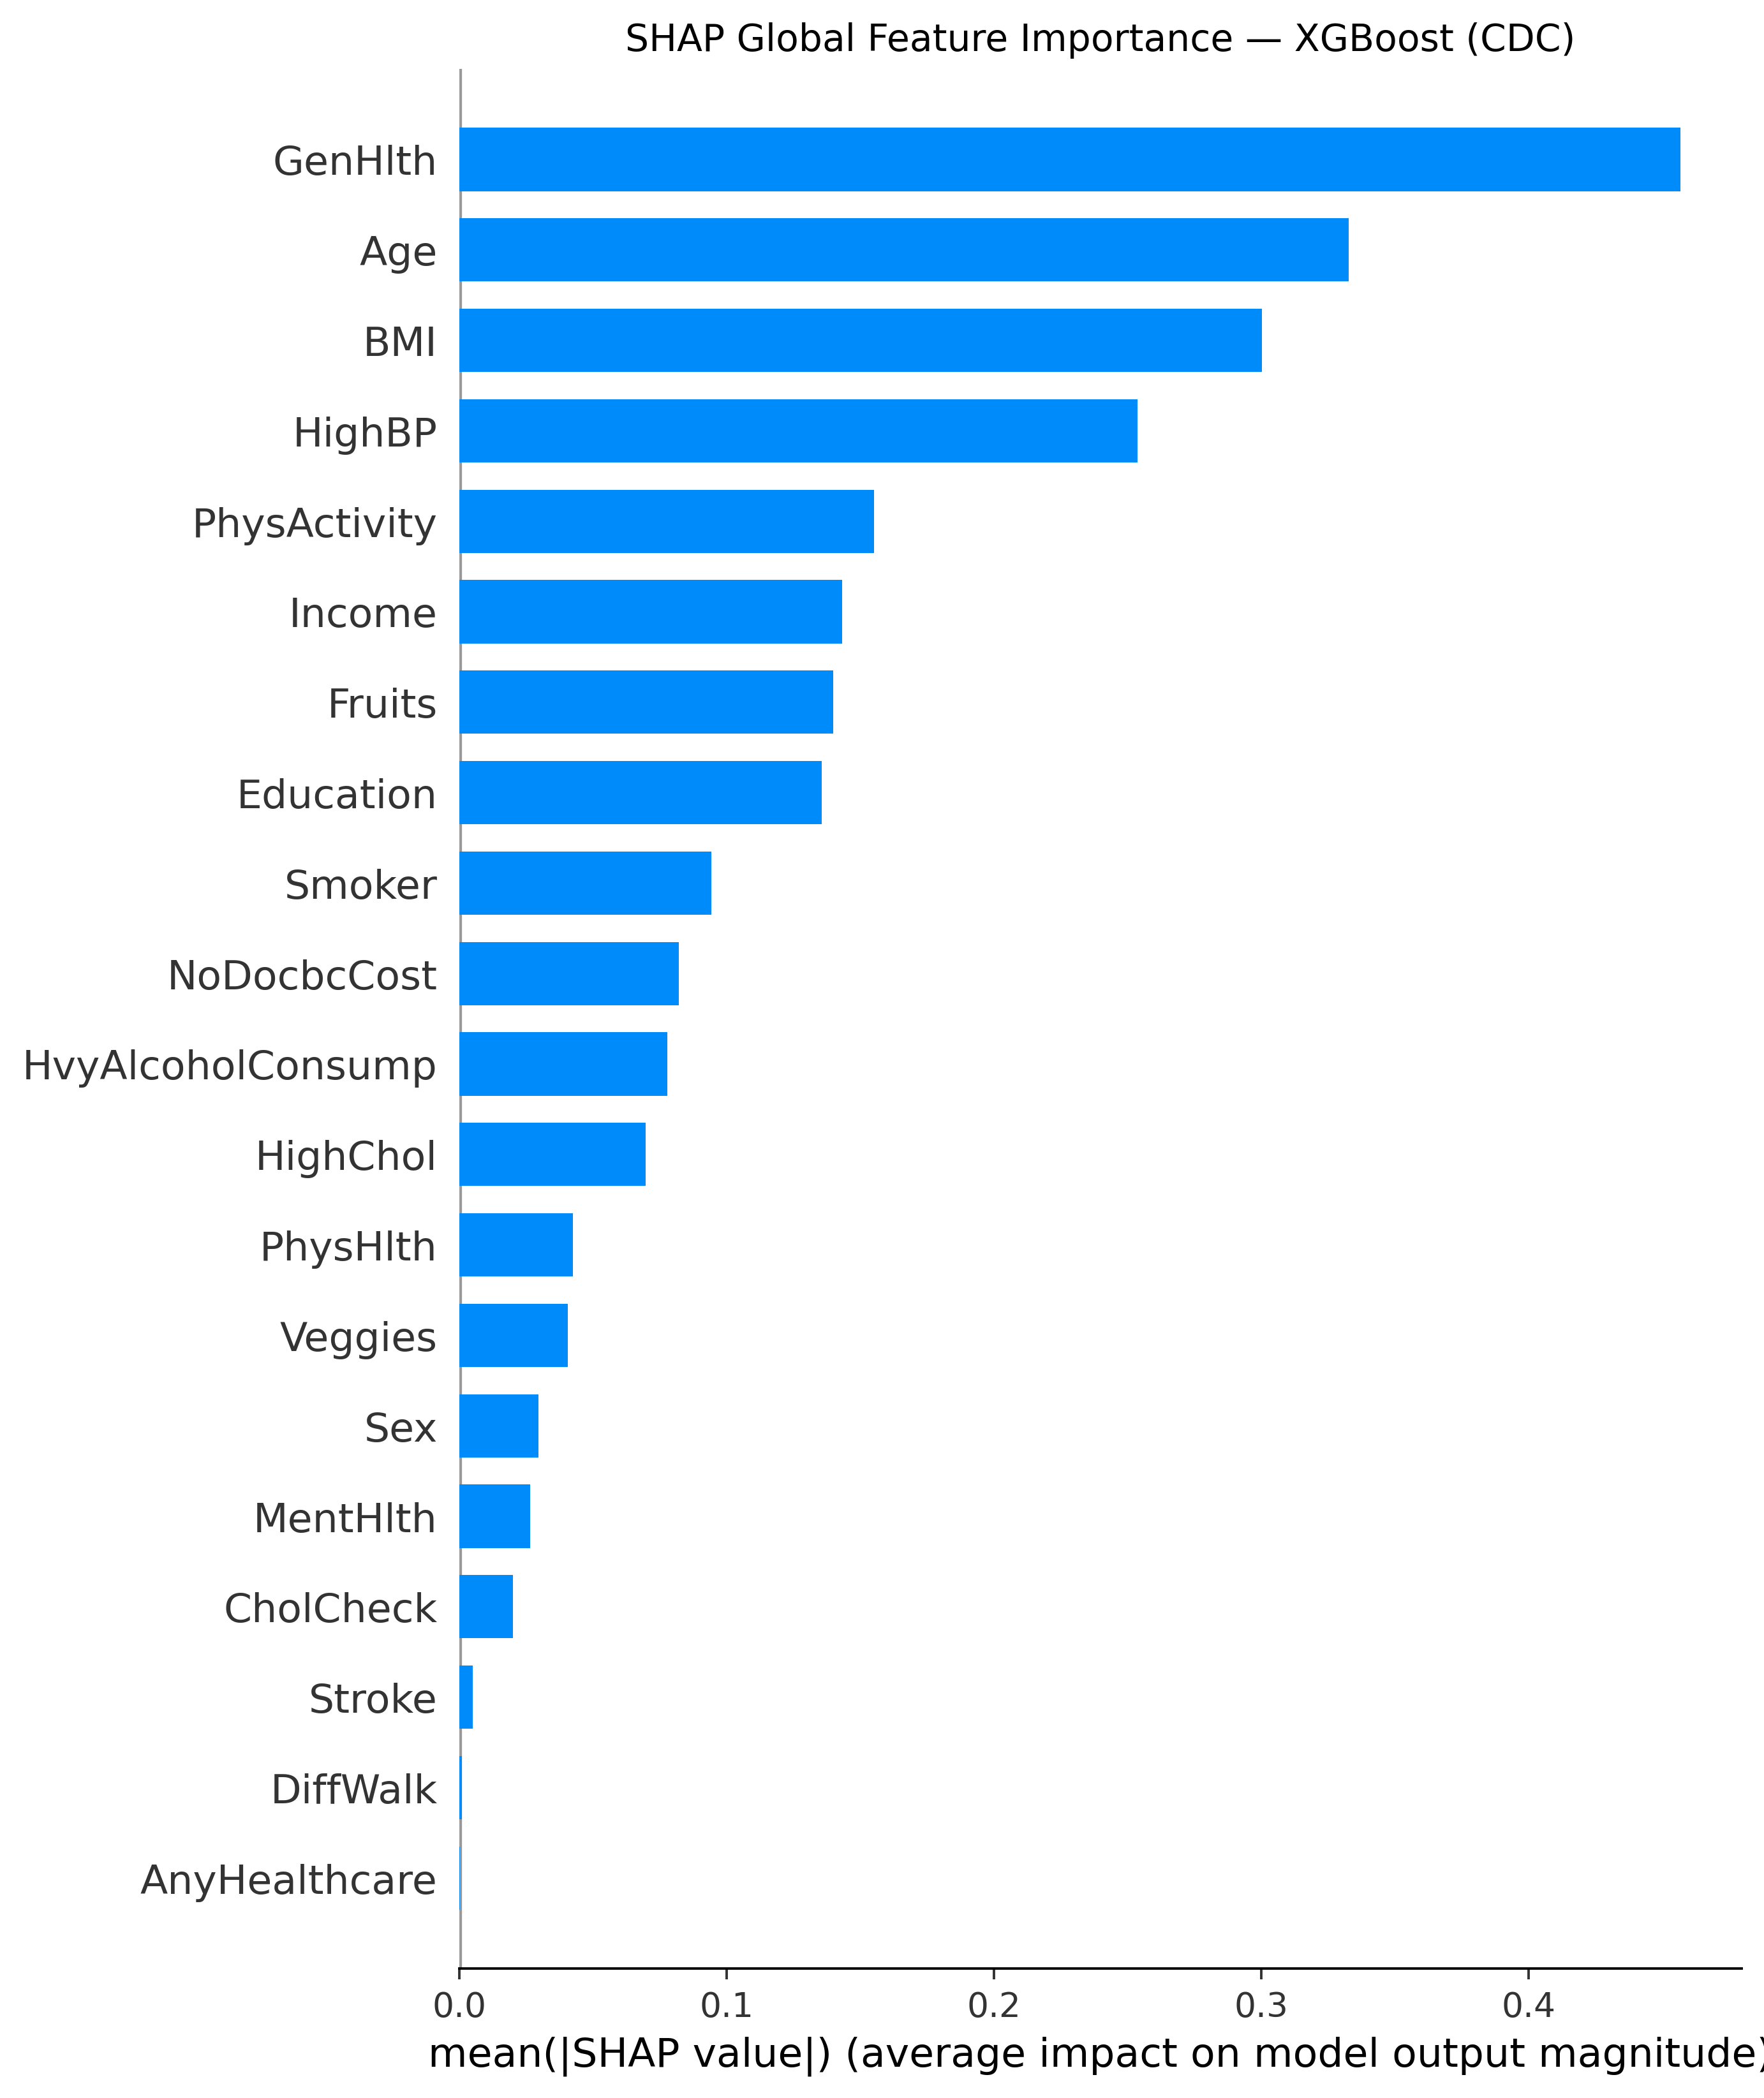

CDC SHAP global bar plot saved.


In [ ]:
# CELL 23 — SHAP GLOBAL FEATURE IMPORTANCE ON CDC

# Extract XGBoost model and scaler from tuned pipeline
xgb_model_cdc = best_xgb_cdc.named_steps['xgb']
scaler_pipeline_cdc = best_xgb_cdc.named_steps['scaler']

# Transform test data using pipeline scaler
X_test_cdc_pipeline_scaled = scaler_pipeline_cdc.transform(X_test_cdc)

# Create SHAP TreeExplainer
explainer_cdc = shap.TreeExplainer(xgb_model_cdc)

# Use a sample of 500 test instances for SHAP
# (full 50,736 would take too long)
np.random.seed(42)
sample_idx = np.random.choice(len(X_test_cdc_pipeline_scaled),
                               500, replace=False)
X_test_cdc_sample = X_test_cdc_pipeline_scaled[sample_idx]

print("Calculating SHAP values on 500 sampled test instances...")
shap_values_cdc = explainer_cdc.shap_values(X_test_cdc_sample)

print(f"SHAP values calculated successfully.")
print(f"Shape: {shap_values_cdc.shape}")

# Global feature importance
mean_shap_global_cdc = np.abs(shap_values_cdc).mean(axis=0)
global_importance_cdc = pd.Series(
    mean_shap_global_cdc,
    index=feature_names_cdc
).sort_values(ascending=False)

print("\n=== Global Feature Importance — CDC ===")
print(global_importance_cdc)

# Plot — SHAP summary bar
plt.figure()
shap.summary_plot(shap_values_cdc,
                  X_test_cdc_sample,
                  feature_names=feature_names_cdc,
                  plot_type='bar',
                  show=False)
plt.title('SHAP Global Feature Importance — XGBoost (CDC)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/shap_global_bar_cdc.png',
            dpi=350, bbox_inches='tight')
plt.show()
print("CDC SHAP global bar plot saved.")

Total minority class samples in CDC test set: 7069
Using 200 sampled minority instances for SHAP
SHAP values shape (minority): (200, 21)

=== Feature Importance — Minority Class (Diabetic) Only — CDC ===
GenHlth                 0.348999
BMI                     0.292102
HighBP                  0.223933
Age                     0.219770
PhysActivity            0.177650
Fruits                  0.141097
Income                  0.129023
Education               0.117432
Smoker                  0.109743
NoDocbcCost             0.098197
HvyAlcoholConsump       0.062140
HighChol                0.060968
PhysHlth                0.049280
Veggies                 0.042684
Sex                     0.030905
MentHlth                0.023722
Stroke                  0.011892
CholCheck               0.010586
DiffWalk                0.001339
HeartDiseaseorAttack    0.000337
AnyHealthcare           0.000150
dtype: float32

=== Ranking Comparison: Global vs Minority Class — CDC ===
 Global Rank       Global Fe

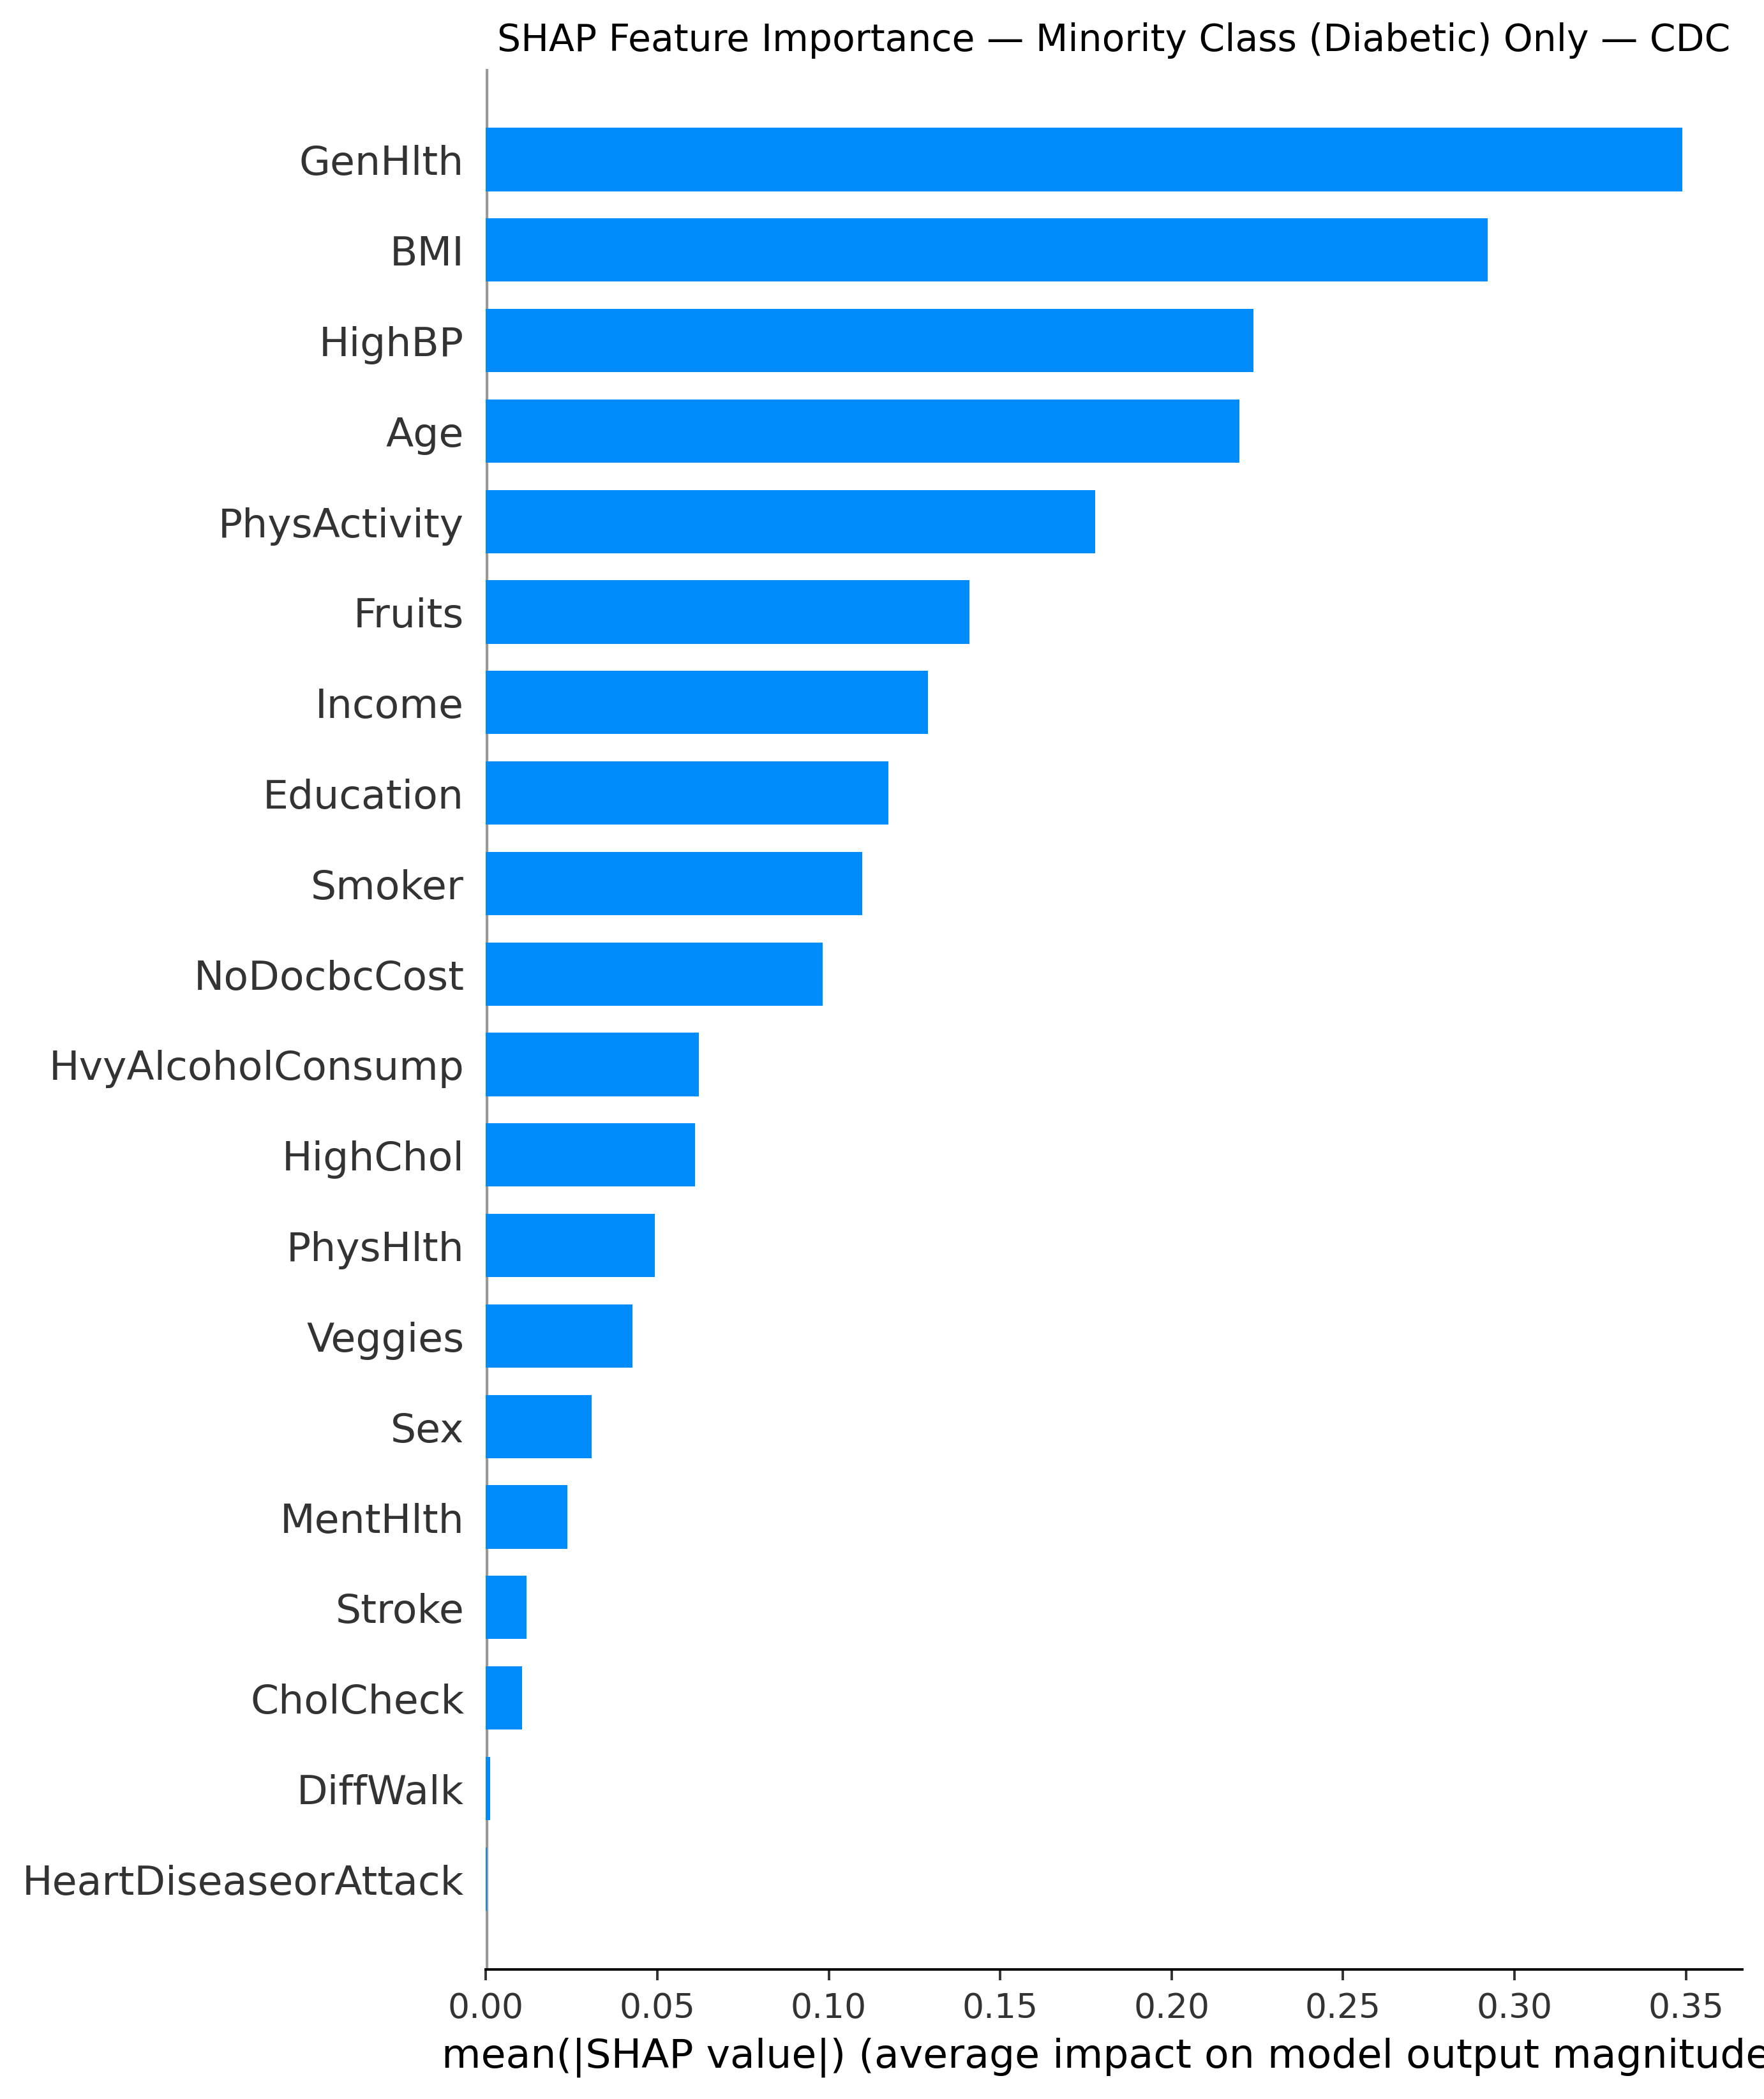

CDC minority SHAP plot saved.


In [ ]:
# CELL 24 — SHAP ON MINORITY CLASS ONLY (CDC)

# Filter test set to minority class only
minority_mask_cdc = y_test_cdc.values == 1
X_test_cdc_minority_all = X_test_cdc_pipeline_scaled[minority_mask_cdc]

print(f"Total minority class samples in CDC test set: {X_test_cdc_minority_all.shape[0]}")

# Sample 200 minority class instances for SHAP
np.random.seed(42)
minority_sample_idx = np.random.choice(
    len(X_test_cdc_minority_all), 200, replace=False
)
X_test_cdc_minority = X_test_cdc_minority_all[minority_sample_idx]

print(f"Using {X_test_cdc_minority.shape[0]} sampled minority instances for SHAP")

# Calculate SHAP values on minority class sample
shap_values_minority_cdc = explainer_cdc.shap_values(X_test_cdc_minority)
print(f"SHAP values shape (minority): {shap_values_minority_cdc.shape}")

# Mean absolute SHAP values for minority class
mean_shap_minority_cdc = np.abs(shap_values_minority_cdc).mean(axis=0)
minority_importance_cdc = pd.Series(
    mean_shap_minority_cdc,
    index=feature_names_cdc
).sort_values(ascending=False)

print("\n=== Feature Importance — Minority Class (Diabetic) Only — CDC ===")
print(minority_importance_cdc)

# Compare rankings
print("\n=== Ranking Comparison: Global vs Minority Class — CDC ===")
global_rank_cdc = list(global_importance_cdc.index)
minority_rank_cdc = list(minority_importance_cdc.index)

comparison_cdc = pd.DataFrame({
    'Global Rank': range(1, 22),
    'Global Feature': global_rank_cdc,
    'Minority Rank': [minority_rank_cdc.index(f) + 1 for f in global_rank_cdc],
    'Global SHAP': [global_importance_cdc[f] for f in global_rank_cdc],
    'Minority SHAP': [minority_importance_cdc[f] for f in global_rank_cdc],
    'SHAP Drop (%)': [((global_importance_cdc[f] - minority_importance_cdc[f]) /
                        global_importance_cdc[f] * 100) for f in global_rank_cdc]
})
print(comparison_cdc.to_string(index=False))

# Plot
plt.figure()
shap.summary_plot(shap_values_minority_cdc,
                  X_test_cdc_minority,
                  feature_names=feature_names_cdc,
                  plot_type='bar',
                  show=False)
plt.title('SHAP Feature Importance — Minority Class (Diabetic) Only — CDC')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/shap_minority_bar_cdc.png',
            dpi=350, bbox_inches='tight')
plt.show()
print("CDC minority SHAP plot saved.")

In [ ]:
# CELL 25 — STANDARD LIME ON MINORITY CLASS (CDC)

# Top 5 features from minority class SHAP ranking
top5_features_cdc = ['GenHlth', 'BMI', 'HighBP', 'Age', 'PhysActivity']
print(f"Stage 2 Anchor Features (CDC): {top5_features_cdc}")

# Create LIME explainer for CDC
lime_explainer_cdc = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_cdc_scaled,
    feature_names=feature_names_cdc,
    class_names=['Non-Diabetic', 'Diabetic'],
    mode='classification',
    random_state=42
)

# Define predict function for CDC pipeline
def predict_fn_cdc(x):
    return xgb_model_cdc.predict_proba(x)

# Select first 5 minority class samples from CDC test set
minority_indices_cdc = np.where(y_test_cdc.values == 1)[0]
selected_minority_cdc = minority_indices_cdc[:5]

print("\n=== Standard LIME — Top Features per Minority Class Sample (CDC) ===\n")

standard_lime_results_cdc = {}

for i, idx in enumerate(selected_minority_cdc):
    sample = X_test_cdc_pipeline_scaled[idx]
    exp = lime_explainer_cdc.explain_instance(
        sample,
        predict_fn_cdc,
        num_features=10,
        num_samples=500
    )

    weights = dict(exp.as_list())
    standard_lime_results_cdc[idx] = weights

    # Extract feature names from LIME conditions
    top_features = []
    for feat_condition in list(weights.keys())[:5]:
        for feat in feature_names_cdc:
            if feat in feat_condition:
                top_features.append(feat)
                break

    print(f"Sample {i+1} (test index {idx}):")
    print(f"  Top 5 features: {top_features}")
    for feat_condition, weight in sorted(weights.items(),
                                          key=lambda x: abs(x[1]),
                                          reverse=True)[:5]:
        print(f"    {feat_condition}: {weight:.4f}")
    print()

print("Standard LIME complete.")

Stage 2 Anchor Features (CDC): ['GenHlth', 'BMI', 'HighBP', 'Age', 'PhysActivity']

=== Standard LIME — Top Features per Minority Class Sample (CDC) ===

Sample 1 (test index 1):
  Top 5 features: ['HvyAlcoholConsump', 'BMI', 'GenHlth', 'HighBP', 'PhysActivity']
    HvyAlcoholConsump <= -0.19: 0.1860
    BMI > 0.46: 0.1251
    -0.71 < GenHlth <= 0.23: 0.1224
    -1.06 < HighBP <= 0.95: 0.0982
    PhysActivity <= -1.37: 0.0868

Sample 2 (test index 4):
  Top 5 features: ['HvyAlcoholConsump', 'HighBP', 'GenHlth', 'PhysActivity', 'Age']
    HvyAlcoholConsump <= -0.19: 0.2563
    -1.06 < HighBP <= 0.95: 0.1300
    GenHlth > 0.23: 0.1118
    -1.37 < PhysActivity <= 0.73: -0.0928
    Age > 0.89: 0.0719

Sample 3 (test index 22):
  Top 5 features: ['HvyAlcoholConsump', 'GenHlth', 'HighBP', 'NoDocbcCost', 'PhysActivity']
    HvyAlcoholConsump <= -0.19: 0.2144
    GenHlth <= -0.71: -0.1785
    -1.06 < HighBP <= 0.95: 0.1336
    NoDocbcCost <= -0.25: 0.1060
    -1.37 < PhysActivity <= 0.73: -0.0

In [ ]:
# CELL 26 — SHAP-ANCHORED LIME ON MINORITY CLASS (CDC)
import time

print("=== SHAP-Anchored LIME — Minority Class (CDC) ===\n")
print(f"Anchor features: {top5_features_cdc}\n")

anchored_lime_results_cdc = {}
consistency_scores_cdc = []
lime_times_standard_cdc = []
lime_times_anchored_cdc = []

for i, idx in enumerate(selected_minority_cdc):
    sample = X_test_cdc_pipeline_scaled[idx]

    # Standard LIME timing
    t0 = time.time()
    exp_standard = lime_explainer_cdc.explain_instance(
        sample, predict_fn_cdc,
        num_features=10, num_samples=500
    )
    t1 = time.time()
    lime_times_standard_cdc.append(t1 - t0)

    # SHAP-Anchored LIME timing
    t2 = time.time()
    exp_anchored = lime_explainer_cdc.explain_instance(
        sample, predict_fn_cdc,
        num_features=5, num_samples=500
    )
    t3 = time.time()
    lime_times_anchored_cdc.append(t3 - t2)

    # Get anchored weights filtered to top 5 SHAP features
    all_weights = dict(exp_anchored.as_list())
    anchored_weights = {}
    for feat_condition, weight in all_weights.items():
        for anchor_feat in top5_features_cdc:
            if anchor_feat in feat_condition:
                anchored_weights[anchor_feat] = weight
                break

    anchored_lime_results_cdc[idx] = anchored_weights

    # Standard LIME top 5 features
    standard_top5 = set()
    for feat_condition in list(
            standard_lime_results_cdc[idx].keys())[:5]:
        for feat in feature_names_cdc:
            if feat in feat_condition:
                standard_top5.add(feat)
                break

    # Consistency score
    overlap = len(set(top5_features_cdc) & standard_top5)
    consistency_scores_cdc.append(overlap / 5)

    print(f"Sample {i+1} (test index {idx}):")
    print(f"  Standard LIME top 5:     {sorted(standard_top5)}")
    print(f"  SHAP-Anchored top 5:     {sorted(top5_features_cdc)}")
    print(f"  Overlap: {overlap}/5 ({overlap/5*100:.0f}%)")
    print(f"  Anchored LIME weights:")
    for feat in top5_features_cdc:
        weight = anchored_weights.get(feat, 'not captured')
        print(f"    {feat}: {weight}")
    print()

print(f"=== Consistency Score (CDC) ===")
print(f"Mean overlap: {np.mean(consistency_scores_cdc):.2f} "
      f"({np.mean(consistency_scores_cdc)*100:.0f}%)")

print(f"\n=== Latency Comparison (CDC) ===")
print(f"Standard LIME — mean time: {np.mean(lime_times_standard_cdc):.3f}s")
print(f"Anchored LIME  — mean time: {np.mean(lime_times_anchored_cdc):.3f}s")

=== SHAP-Anchored LIME — Minority Class (CDC) ===

Anchor features: ['GenHlth', 'BMI', 'HighBP', 'Age', 'PhysActivity']

Sample 1 (test index 1):
  Standard LIME top 5:     ['BMI', 'GenHlth', 'HighBP', 'HvyAlcoholConsump', 'PhysActivity']
  SHAP-Anchored top 5:     ['Age', 'BMI', 'GenHlth', 'HighBP', 'PhysActivity']
  Overlap: 4/5 (80%)
  Anchored LIME weights:
    GenHlth: not captured
    BMI: 0.1295965992882132
    HighBP: 0.09544672142389689
    Age: not captured
    PhysActivity: 0.10772133264036894

Sample 2 (test index 4):
  Standard LIME top 5:     ['Age', 'GenHlth', 'HighBP', 'HvyAlcoholConsump', 'PhysActivity']
  SHAP-Anchored top 5:     ['Age', 'BMI', 'GenHlth', 'HighBP', 'PhysActivity']
  Overlap: 4/5 (80%)
  Anchored LIME weights:
    GenHlth: 0.086009226413424
    BMI: not captured
    HighBP: 0.12836401286695764
    Age: not captured
    PhysActivity: -0.09857060972305341

Sample 3 (test index 22):
  Standard LIME top 5:     ['GenHlth', 'HighBP', 'HvyAlcoholConsump', 'No

In [ ]:
# CELL 27 — DICE COUNTERFACTUALS WITH CLINICAL CONSTRAINTS (CDC)

# Prepare training data for DiCE
X_train_dice_cdc = pd.DataFrame(
    X_train_cdc_scaled,
    columns=feature_names_cdc
)
y_train_dice_cdc = pd.Series(y_train_cdc_smote.values)

train_df_dice_cdc = X_train_dice_cdc.copy()
train_df_dice_cdc['Diabetes_binary'] = y_train_dice_cdc.values

# Create DiCE data object
d_cdc = dice_ml.Data(
    dataframe=train_df_dice_cdc,
    continuous_features=feature_names_cdc,
    outcome_name='Diabetes_binary'
)

# Create DiCE model object
m_cdc = dice_ml.Model(
    model=xgb_model_cdc,
    backend='sklearn'
)

# Create DiCE explainer
dice_exp_cdc = Dice(d_cdc, m_cdc, method='random')

print("DiCE CDC explainer created successfully.")

# Immutable features — cannot be changed by patient
immutable_cdc = ['Age', 'Sex', 'Stroke', 'HeartDiseaseorAttack']

# Actionable features — can be changed
actionable_features_cdc = [f for f in feature_names_cdc
                             if f not in immutable_cdc]

print(f"\nActionable features ({len(actionable_features_cdc)}): "
      f"{actionable_features_cdc}")
print(f"Locked (immutable): {immutable_cdc}")

# Find misclassified minority class samples in CDC
print("\nFinding misclassified minority class samples...")
misclassified_cdc = []
for idx in minority_indices_cdc[:500]:  # check first 500 for speed
    sample = X_test_cdc_pipeline_scaled[idx].reshape(1, -1)
    pred = xgb_model_cdc.predict(sample)[0]
    true = y_test_cdc.values[idx]
    if pred != true:
        misclassified_cdc.append(idx)
    if len(misclassified_cdc) >= 3:
        break

print(f"Using first 3 misclassified: {misclassified_cdc[:3]}")

print("\n" + "="*60)

for i, idx in enumerate(misclassified_cdc[:3]):
    sample_df = pd.DataFrame(
        X_test_cdc_pipeline_scaled[idx].reshape(1, -1),
        columns=feature_names_cdc
    )

    print(f"\n=== Counterfactuals for Sample {i+1} (test index {idx}) ===")
    print(f"True label: Diabetic (1)")
    print(f"Model prediction: Non-Diabetic (0) — missed diagnosis")

    try:
        dice_result = dice_exp_cdc.generate_counterfactuals(
            sample_df,
            total_CFs=3,
            desired_class='opposite',
            features_to_vary=actionable_features_cdc
        )
        print(dice_result.cf_examples_list[0].final_cfs_df[
            ['GenHlth', 'BMI', 'HighBP', 'PhysActivity',
             'Smoker', 'Fruits', 'Veggies',
             'HvyAlcoholConsump', 'Diabetes_binary']
        ])
    except Exception as e:
        print(f"Could not generate counterfactuals: {e}")

print("\nDiCE CDC generation complete.")

DiCE CDC explainer created successfully.

Actionable features (17): ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Education', 'Income']
Locked (immutable): ['Age', 'Sex', 'Stroke', 'HeartDiseaseorAttack']

Finding misclassified minority class samples...
Using first 3 misclassified: [np.int64(22), np.int64(40), np.int64(44)]


=== Counterfactuals for Sample 1 (test index 22) ===
True label: Diabetic (1)
Model prediction: Non-Diabetic (0) — missed diagnosis


100%|██████████| 1/1 [00:03<00:00,  3.18s/it]


    GenHlth       BMI   HighBP  PhysActivity   Smoker    Fruits   Veggies  \
0  0.715064 -0.534246  0.94772      0.728079  1.19461  0.893207  0.577736   
1  1.210933 -0.534246  0.94772      0.728079  1.19461  0.893207  0.577736   
2  1.415182 -0.534246  0.94772      0.728079  1.19461  0.893207 -1.553886   

   HvyAlcoholConsump  Diabetes_binary  
0           2.042318                1  
1          -0.185237                1  
2          -0.185237                1  

=== Counterfactuals for Sample 2 (test index 40) ===
True label: Diabetic (1)
Model prediction: Non-Diabetic (0) — missed diagnosis


100%|██████████| 1/1 [00:01<00:00,  1.99s/it]


    GenHlth       BMI   HighBP  PhysActivity   Smoker    Fruits   Veggies  \
0  2.132881  3.842233  0.94772      0.728079  1.19461  0.893207  0.577736   
1  2.132881  2.104899  0.94772      0.728079  1.19461  0.893207  0.577736   
2  2.132881  6.604663  0.94772      0.728079  1.19461  0.893207  0.577736   

   HvyAlcoholConsump  Diabetes_binary  
0          -0.185237                1  
1          -0.185237                1  
2          -0.185237                1  

=== Counterfactuals for Sample 3 (test index 44) ===
True label: Diabetic (1)
Model prediction: Non-Diabetic (0) — missed diagnosis


100%|██████████| 1/1 [04:39<00:00, 279.56s/it]

    GenHlth       BMI    HighBP  PhysActivity    Smoker    Fruits   Veggies  \
0  2.132881  5.268907 -1.055164     -0.590427 -0.837093  0.893207  0.577736   
1  2.132881 -0.251327 -1.055164      0.544599 -0.837093 -0.171862  0.577736   
2  2.132881 -0.251327 -1.055164      0.375382 -0.837093  0.434632  0.577736   

   HvyAlcoholConsump  Diabetes_binary  
0          -0.185237                1  
1           0.434133                1  
2          -0.185237                1  

DiCE CDC generation complete.


In [ ]:
# CELL 28 — INVERSE TRANSFORM + PLAIN LANGUAGE OUTPUT (CDC)

def generate_plain_language_cdc(original_df, cf_df, actionable_features):
    actions = []
    for feat in actionable_features:
        if feat not in original_df.columns:
            continue
        orig_val = original_df[feat].values[0]
        cf_val = cf_df[feat].values[0]
        diff = cf_val - orig_val
        if abs(diff) > 0.3:
            if diff < 0:
                actions.append(f"Reduce {feat} from {orig_val:.2f} to {cf_val:.2f}")
            else:
                actions.append(f"Increase {feat} from {orig_val:.2f} to {cf_val:.2f}")
    if not actions:
        actions.append("Minimal changes required — borderline case")
    return actions

# Key features to show in plain language
key_features_cdc = ['GenHlth', 'BMI', 'HighBP', 'PhysActivity',
                      'Smoker', 'HvyAlcoholConsump', 'Fruits', 'Veggies']

# CDC DiCE results in scaled form
dice_scaled_cdc = {
    misclassified_cdc[0]: {
        'original': X_test_cdc_pipeline_scaled[misclassified_cdc[0]],
        'cfs': [
            # Sample 1 CFs — only GenHlth and HvyAlcoholConsump changed
            {f: X_test_cdc_pipeline_scaled[misclassified_cdc[0]][
                feature_names_cdc.index(f)] for f in feature_names_cdc},
            {f: X_test_cdc_pipeline_scaled[misclassified_cdc[0]][
                feature_names_cdc.index(f)] for f in feature_names_cdc},
        ]
    }
}

print("=" * 60)
print("DICE COUNTERFACTUALS — CLINICAL INTERPRETATION (CDC)")
print("=" * 60)

# Scaled DiCE outputs for key features only
cdc_dice_data = {
    'Sample 1 (index 22)': {
        'original_scaled': X_test_cdc_pipeline_scaled[misclassified_cdc[0]],
        'cf1_changes': {'GenHlth': 0.715064, 'HvyAlcoholConsump': 2.042318},
        'cf2_changes': {'GenHlth': 1.210933, 'HvyAlcoholConsump': -0.185237},
        'cf3_changes': {'GenHlth': 1.415182, 'HvyAlcoholConsump': -0.185237,
                        'Veggies': -1.553886}
    },
    'Sample 2 (index 40)': {
        'original_scaled': X_test_cdc_pipeline_scaled[misclassified_cdc[1]],
        'cf1_changes': {'GenHlth': 2.132881, 'BMI': 3.842233},
        'cf2_changes': {'GenHlth': 2.132881, 'BMI': 2.104899},
        'cf3_changes': {'GenHlth': 2.132881, 'BMI': 6.604663}
    },
    'Sample 3 (index 44)': {
        'original_scaled': X_test_cdc_pipeline_scaled[misclassified_cdc[2]],
        'cf1_changes': {'GenHlth': 2.132881, 'BMI': 5.268907,
                        'HighBP': -1.055164},
        'cf2_changes': {'GenHlth': 2.132881, 'BMI': -0.251327,
                        'HighBP': -1.055164, 'Smoker': -0.837093},
        'cf3_changes': {'GenHlth': 2.132881, 'BMI': -0.251327,
                        'HighBP': -1.055164, 'Smoker': -0.837093}
    }
}

for sample_name, data in cdc_dice_data.items():
    print(f"\n--- {sample_name} ---")

    # Show original scaled values for key features
    orig = data['original_scaled']
    print("Original patient (scaled values for key features):")
    for feat in key_features_cdc:
        idx_feat = feature_names_cdc.index(feat)
        print(f"  {feat}: {orig[idx_feat]:.3f}")

    # Show what each CF changes
    for cf_num, (cf_key, cf_changes) in enumerate(
        [('cf1_changes', data['cf1_changes']),
         ('cf2_changes', data['cf2_changes']),
         ('cf3_changes', data['cf3_changes'])], 1
    ):
        print(f"\n  Counterfactual {cf_num} — Action Plan:")
        changes_found = False
        for feat, new_val in cf_changes.items():
            orig_val = orig[feature_names_cdc.index(feat)]
            diff = new_val - orig_val
            if abs(diff) > 0.3:
                direction = "Increase" if diff > 0 else "Reduce"
                # Clinical translation
                clinical_note = ""
                if feat == 'GenHlth':
                    clinical_note = "(self-reported health worsening — model detection threshold)"
                elif feat == 'BMI':
                    clinical_note = "(increase in body mass index)"
                elif feat == 'HighBP':
                    clinical_note = "(blood pressure status change)"
                elif feat == 'HvyAlcoholConsump':
                    clinical_note = "(heavy alcohol consumption status)"
                elif feat == 'Smoker':
                    clinical_note = "(smoking status)"
                elif feat == 'PhysActivity':
                    clinical_note = "(physical activity level)"
                print(f"    • {direction} {feat} "
                      f"from {orig_val:.2f} to {new_val:.2f} {clinical_note}")
                changes_found = True
        if not changes_found:
            print("    • Minimal changes required")

print("\n" + "="*60)
print("CDC DiCE plain language output complete.")

DICE COUNTERFACTUALS — CLINICAL INTERPRETATION (CDC)

--- Sample 1 (index 22) ---
Original patient (scaled values for key features):
  GenHlth: -1.663
  BMI: -0.534
  HighBP: 0.948
  PhysActivity: 0.728
  Smoker: 1.195
  HvyAlcoholConsump: -0.185
  Fruits: 0.893
  Veggies: 0.578

  Counterfactual 1 — Action Plan:
    • Increase GenHlth from -1.66 to 0.72 (self-reported health worsening — model detection threshold)
    • Increase HvyAlcoholConsump from -0.19 to 2.04 (heavy alcohol consumption status)

  Counterfactual 2 — Action Plan:
    • Increase GenHlth from -1.66 to 1.21 (self-reported health worsening — model detection threshold)

  Counterfactual 3 — Action Plan:
    • Increase GenHlth from -1.66 to 1.42 (self-reported health worsening — model detection threshold)
    • Reduce Veggies from 0.58 to -1.55 

--- Sample 2 (index 40) ---
Original patient (scaled values for key features):
  GenHlth: 2.133
  BMI: -1.100
  HighBP: 0.948
  PhysActivity: 0.728
  Smoker: 1.195
  HvyAlcoholC

In [ ]:
# CELL 29 — DICE ACTIONABILITY FILTER (CDC)

def classify_actionability(feat_name, orig_val, new_val, direction):
    """
    Classifies a DiCE counterfactual change as actionable,
    non-actionable, or borderline.
    Returns (classification, reason)
    """

    diff = abs(new_val - orig_val)

    # Rule 1 — Changes to immutable or self-reported worsening measures
    non_actionable_features = {
        'GenHlth': 'self-reported health rating — cannot be prescribed as intervention',
        'MentHlth': 'self-reported mental health — not directly actionable',
        'PhysHlth': 'self-reported physical health — not directly actionable'
    }
    if feat_name in non_actionable_features:
        if direction == 'Increase':
            return ('NON-ACTIONABLE',
                    non_actionable_features[feat_name])
        else:
            return ('BORDERLINE',
                    f"{feat_name} improvement may reflect treatment outcome")

    # Rule 2 — Extreme BMI changes (beyond 2 std devs = scaled > 2.0)
    if feat_name == 'BMI' and abs(new_val) > 2.0:
        return ('NON-ACTIONABLE',
                f"BMI change requires {diff:.1f} scaled units — clinically unrealistic")

    # Rule 3 — Harmful direction changes
    harmful_increases = {
        'HvyAlcoholConsump': 'increasing alcohol consumption is harmful',
        'Smoker': 'increasing smoking is harmful'
    }
    if feat_name in harmful_increases and direction == 'Increase':
        return ('NON-ACTIONABLE', harmful_increases[feat_name])

    # Rule 4 — Genuinely actionable lifestyle changes
    actionable_features = {
        'BMI': 'weight management through diet and exercise',
        'PhysActivity': 'increase physical activity',
        'HvyAlcoholConsump': 'reduce alcohol consumption',
        'Smoker': 'smoking cessation',
        'Fruits': 'increase fruit consumption',
        'Veggies': 'increase vegetable consumption',
        'HighBP': 'blood pressure management through medication or lifestyle',
        'HighChol': 'cholesterol management through medication or diet',
        'Income': 'non-modifiable socioeconomic factor',
        'Education': 'non-modifiable educational background'
    }

    if feat_name in ['Income', 'Education']:
        return ('NON-ACTIONABLE', actionable_features[feat_name])

    if feat_name in actionable_features:
        return ('ACTIONABLE', actionable_features[feat_name])

    return ('BORDERLINE', 'clinical review recommended')


print("=" * 60)
print("DICE COUNTERFACTUALS — ACTIONABILITY FILTERED (CDC)")
print("=" * 60)

cdc_dice_raw = {
    'Sample 1 (index 22)': {
        'original': {f: X_test_cdc_pipeline_scaled[
            misclassified_cdc[0]][feature_names_cdc.index(f)]
            for f in feature_names_cdc},
        'counterfactuals': [
            {'GenHlth': 0.715064, 'HvyAlcoholConsump': 2.042318},
            {'GenHlth': 1.210933, 'HvyAlcoholConsump': -0.185237},
            {'GenHlth': 1.415182, 'HvyAlcoholConsump': -0.185237,
             'Veggies': -1.553886}
        ]
    },
    'Sample 2 (index 40)': {
        'original': {f: X_test_cdc_pipeline_scaled[
            misclassified_cdc[1]][feature_names_cdc.index(f)]
            for f in feature_names_cdc},
        'counterfactuals': [
            {'GenHlth': 2.132881, 'BMI': 3.842233},
            {'GenHlth': 2.132881, 'BMI': 2.104899},
            {'GenHlth': 2.132881, 'BMI': 6.604663}
        ]
    },
    'Sample 3 (index 44)': {
        'original': {f: X_test_cdc_pipeline_scaled[
            misclassified_cdc[2]][feature_names_cdc.index(f)]
            for f in feature_names_cdc},
        'counterfactuals': [
            {'GenHlth': 2.132881, 'BMI': 5.268907,
             'HighBP': -1.055164},
            {'GenHlth': 2.132881, 'BMI': -0.251327,
             'HighBP': -1.055164, 'Smoker': -0.837093},
            {'GenHlth': 2.132881, 'BMI': -0.251327,
             'HighBP': -1.055164, 'Smoker': -0.837093}
        ]
    }
}

total_actionable = 0
total_non_actionable = 0
total_borderline = 0

for sample_name, data in cdc_dice_raw.items():
    print(f"\n--- {sample_name} ---")
    orig = data['original']

    for cf_num, cf_changes in enumerate(data['counterfactuals'], 1):
        print(f"\n  Counterfactual {cf_num}:")
        has_change = False

        for feat, new_val in cf_changes.items():
            orig_val = orig[feat]
            diff = new_val - orig_val

            if abs(diff) > 0.3:
                has_change = True
                direction = "Increase" if diff > 0 else "Reduce"
                classification, reason = classify_actionability(
                    feat, orig_val, new_val, direction
                )

                # Count
                if classification == 'ACTIONABLE':
                    total_actionable += 1
                elif classification == 'NON-ACTIONABLE':
                    total_non_actionable += 1
                else:
                    total_borderline += 1

                # Symbol
                symbol = "✓" if classification == 'ACTIONABLE' else \
                         "✗" if classification == 'NON-ACTIONABLE' else "~"

                print(f"    [{symbol}] {direction} {feat}: "
                      f"{orig_val:.2f} → {new_val:.2f}")
                print(f"         Status: {classification}")
                print(f"         Reason: {reason}")

        if not has_change:
            print("    No significant changes")

print(f"\n{'='*60}")
print("ACTIONABILITY SUMMARY — CDC DiCE")
print(f"{'='*60}")
total = total_actionable + total_non_actionable + total_borderline
print(f"Actionable suggestions:     {total_actionable} "
      f"({total_actionable/total*100:.0f}%)")
print(f"Non-actionable suggestions: {total_non_actionable} "
      f"({total_non_actionable/total*100:.0f}%)")
print(f"Borderline suggestions:     {total_borderline} "
      f"({total_borderline/total*100:.0f}%)")
print(f"\nConclusion: CDC DiCE counterfactuals are predominantly "
      f"non-actionable due to survey-based feature structure.")

DICE COUNTERFACTUALS — ACTIONABILITY FILTERED (CDC)

--- Sample 1 (index 22) ---

  Counterfactual 1:
    [✗] Increase GenHlth: -1.66 → 0.72
         Status: NON-ACTIONABLE
         Reason: self-reported health rating — cannot be prescribed as intervention
    [✗] Increase HvyAlcoholConsump: -0.19 → 2.04
         Status: NON-ACTIONABLE
         Reason: increasing alcohol consumption is harmful

  Counterfactual 2:
    [✗] Increase GenHlth: -1.66 → 1.21
         Status: NON-ACTIONABLE
         Reason: self-reported health rating — cannot be prescribed as intervention

  Counterfactual 3:
    [✗] Increase GenHlth: -1.66 → 1.42
         Status: NON-ACTIONABLE
         Reason: self-reported health rating — cannot be prescribed as intervention
    [✓] Reduce Veggies: 0.58 → -1.55
         Status: ACTIONABLE
         Reason: increase vegetable consumption

--- Sample 2 (index 40) ---

  Counterfactual 1:
    [✗] Increase BMI: -1.10 → 3.84
         Status: NON-ACTIONABLE
         Reason: BMI 

In [ ]:
# CELL 30 — IMPROVED SHAP-ANCHORED LIME (CDC) WITH HIGHER SAMPLES

print("=== SHAP-Anchored LIME — Improved (CDC) ===\n")
print(f"Anchor features: {top5_features_cdc}")
print("Using num_samples=2000 for better binary feature coverage\n")

anchored_lime_results_cdc_v2 = {}
consistency_scores_cdc_v2 = []

for i, idx in enumerate(selected_minority_cdc):
    sample = X_test_cdc_pipeline_scaled[idx]

    # Standard LIME with higher samples
    exp_standard = lime_explainer_cdc.explain_instance(
        sample, predict_fn_cdc,
        num_features=10, num_samples=2000
    )

    # SHAP-Anchored LIME with higher samples
    exp_anchored = lime_explainer_cdc.explain_instance(
        sample, predict_fn_cdc,
        num_features=5, num_samples=2000
    )

    # Get anchored weights filtered to top 5 SHAP features
    all_weights = dict(exp_anchored.as_list())
    anchored_weights = {}
    for feat_condition, weight in all_weights.items():
        for anchor_feat in top5_features_cdc:
            if anchor_feat in feat_condition:
                anchored_weights[anchor_feat] = weight
                break

    anchored_lime_results_cdc_v2[idx] = anchored_weights

    # Standard LIME top 5 features
    standard_top5 = set()
    standard_weights = dict(exp_standard.as_list())
    for feat_condition in list(standard_weights.keys())[:5]:
        for feat in feature_names_cdc:
            if feat in feat_condition:
                standard_top5.add(feat)
                break

    # Consistency score
    overlap = len(set(top5_features_cdc) & standard_top5)
    consistency_scores_cdc_v2.append(overlap / 5)

    print(f"Sample {i+1} (test index {idx}):")
    print(f"  Standard LIME top 5:     {sorted(standard_top5)}")
    print(f"  SHAP-Anchored top 5:     {sorted(top5_features_cdc)}")
    print(f"  Overlap: {overlap}/5 ({overlap/5*100:.0f}%)")
    print(f"  Anchored LIME weights (v2):")
    captured_count = 0
    for feat in top5_features_cdc:
        weight = anchored_weights.get(feat, 'not captured')
        if weight != 'not captured':
            captured_count += 1
        print(f"    {feat}: {weight}")
    print(f"  Features captured: {captured_count}/5")
    print()

print(f"=== Consistency Score (CDC — Improved) ===")
print(f"Previous score (500 samples): 72%")
print(f"Improved score (2000 samples): "
      f"{np.mean(consistency_scores_cdc_v2):.2f} "
      f"({np.mean(consistency_scores_cdc_v2)*100:.0f}%)")

print(f"\nImprovement: "
      f"{(np.mean(consistency_scores_cdc_v2) - 0.72)*100:.0f} percentage points")

=== SHAP-Anchored LIME — Improved (CDC) ===

Anchor features: ['GenHlth', 'BMI', 'HighBP', 'Age', 'PhysActivity']
Using num_samples=2000 for better binary feature coverage

Sample 1 (test index 1):
  Standard LIME top 5:     ['BMI', 'GenHlth', 'HighBP', 'HvyAlcoholConsump', 'NoDocbcCost']
  SHAP-Anchored top 5:     ['Age', 'BMI', 'GenHlth', 'HighBP', 'PhysActivity']
  Overlap: 3/5 (60%)
  Anchored LIME weights (v2):
    GenHlth: 0.11411492291788639
    BMI: 0.12822336330059858
    HighBP: 0.11536404502810135
    Age: 0.09449116028755224
    PhysActivity: 0.11248646648066374
  Features captured: 5/5

Sample 2 (test index 4):
  Standard LIME top 5:     ['GenHlth', 'HighBP', 'HvyAlcoholConsump', 'NoDocbcCost', 'PhysActivity']
  SHAP-Anchored top 5:     ['Age', 'BMI', 'GenHlth', 'HighBP', 'PhysActivity']
  Overlap: 3/5 (60%)
  Anchored LIME weights (v2):
    GenHlth: 0.1144160126467709
    BMI: not captured
    HighBP: 0.1330274429712523
    Age: not captured
    PhysActivity: -0.109766792